In [ ]:
!pip install -U git+https://github.com/qubvel/segmentation_models.pytorch

  Cloning https://github.com/qubvel/segmentation_models.pytorch to /tmp/pip-req-build-p_vd6kje
  Running command git clone --filter=blob:none --quiet https://github.com/qubvel/segmentation_models.pytorch /tmp/pip-req-build-p_vd6kje
  Resolved https://github.com/qubvel/segmentation_models.pytorch to commit 625ee55d20bc1cb511c027a394073e594d49b224
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
!pip install pytorch-lightning transformers datasets roboflow

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import PIL
import os
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.data.dataset import Dataset
from segmentation_models_pytorch import Unet
from PIL import Image
import numpy as np
import datasets
import matplotlib.pyplot as plt
import copy
from datasets import Dataset
import torchvision.transforms.functional as TF
from transformers import pipeline
from transformers import SegformerFeatureExtractor, SegformerForSemanticSegmentation



In [ ]:
!pip install transformers
!pip install accelerate
!pip install evaluate
!pip install segmentation-models
!pip install accelerate -U
!python -c "from accelerate.utils import write_basic_config; write_basic_config(mixed_precision='fp16')"
!accelerate env

Configuration already exists at /root/.cache/huggingface/accelerate/default_config.yaml, will not override. Run `accelerate config` manually or pass a different `save_location`.

Copy-and-paste the text below in your GitHub issue

- `Accelerate` version: 1.0.1
- Platform: Linux-6.1.85+-x86_64-with-glibc2.35
- `accelerate` bash location: /usr/local/bin/accelerate
- Python version: 3.10.12
- Numpy version: 1.26.4
- PyTorch version (GPU?): 2.5.0+cu121 (False)
- PyTorch XPU available: False
- PyTorch NPU available: False
- PyTorch MLU available: False
- PyTorch MUSA available: False
- System RAM: 12.67 GB
- `Accelerate` default config:
	- compute_environment: LOCAL_MACHINE
	- distributed_type: NO
	- mixed_precision: fp16
	- use_cpu: True
	- debug: False
	- num_processes: 1
	- machine_rank: 0
	- num_machines: 1
	- rdzv_backend: static
	- same_network: False
	- main_training_function: main
	- enable_cpu_affinity: False
	- downcast_bf16: False
	- tpu_use_cluster: False
	- tpu_use_sudo: False


In [ ]:
image_dir = "/content/drive/MyDrive/Sixray mix/images"
label_dir = "/content/drive/MyDrive/Sixray mix/annotations"

In [ ]:
i2l = os.path.join('/content/', "id2label.json")
import json
f = open (i2l, "r")

# Reading from file
id2label = json.loads(f.read())

id2label = {int(k): v for k, v in id2label.items()}
label2id = {v: k for k, v in id2label.items()}

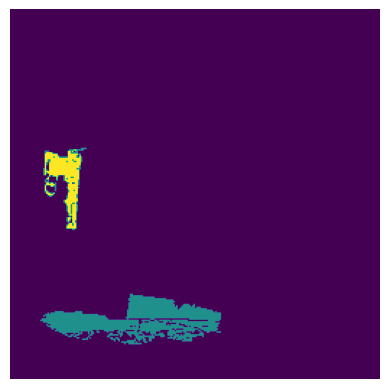

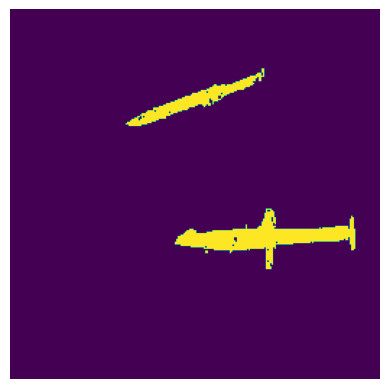

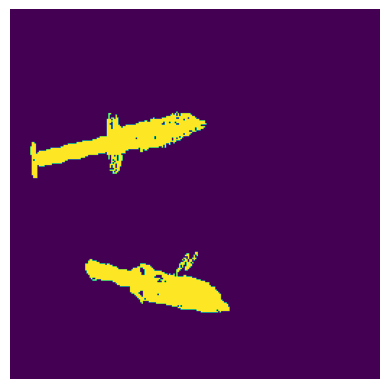

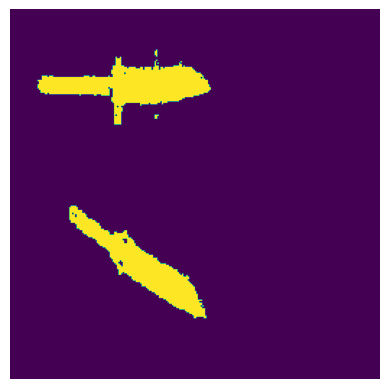

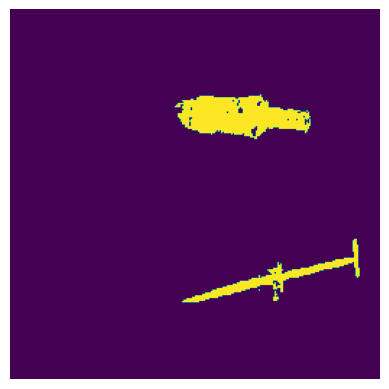

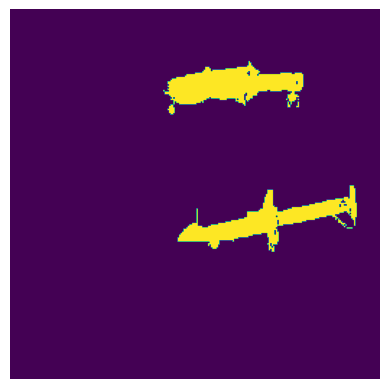

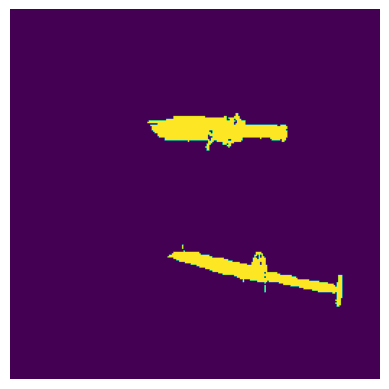

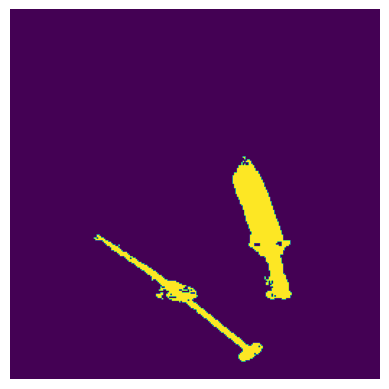

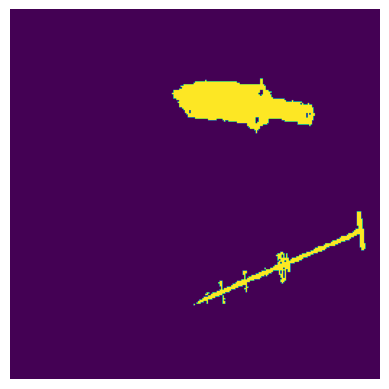

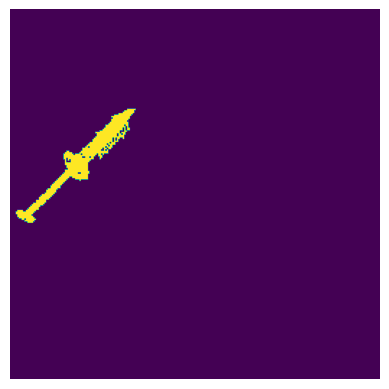

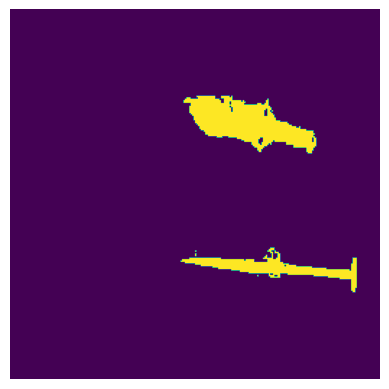

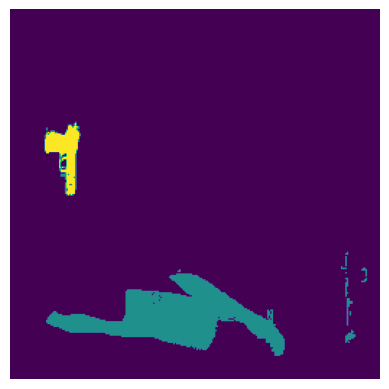

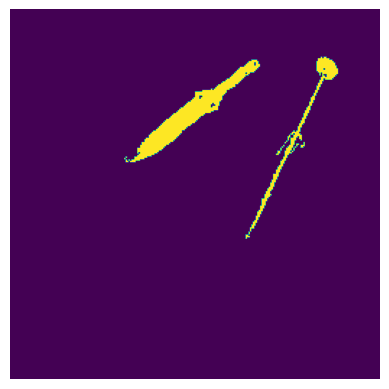

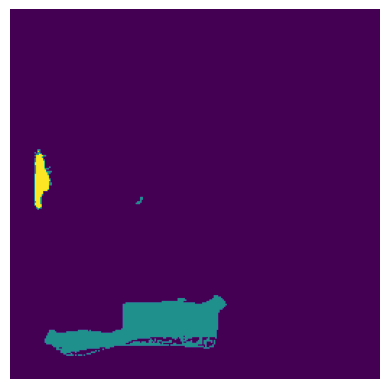

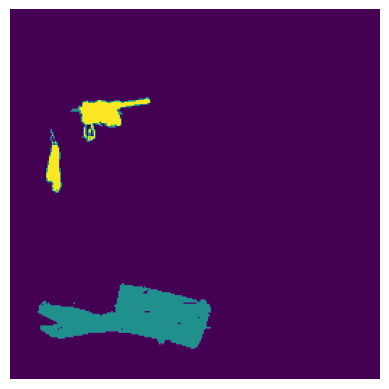

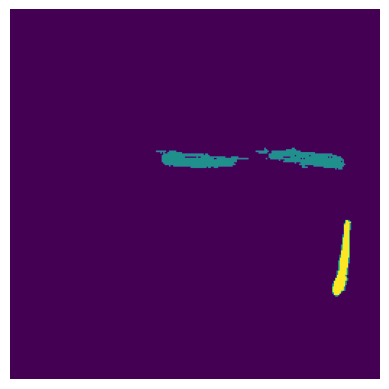

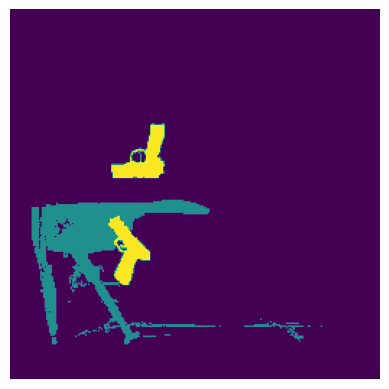

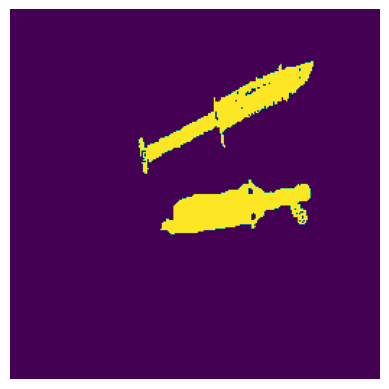

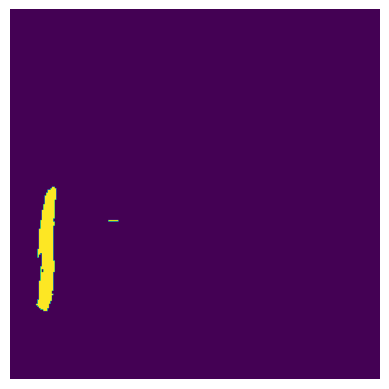

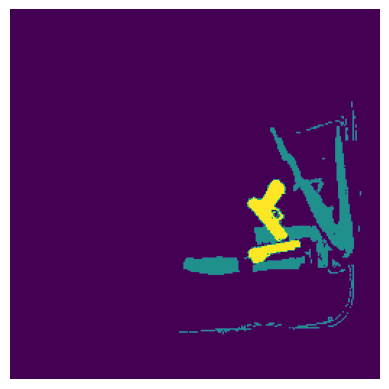

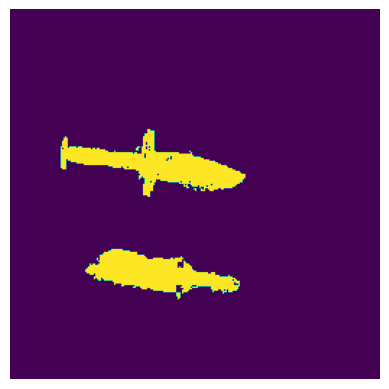

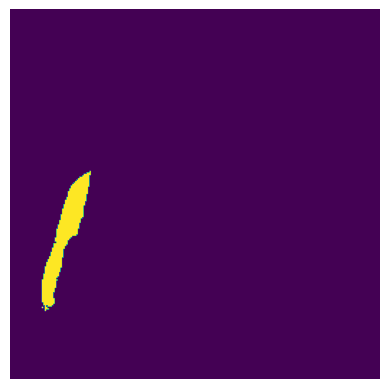

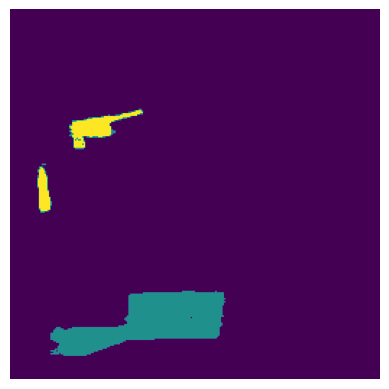

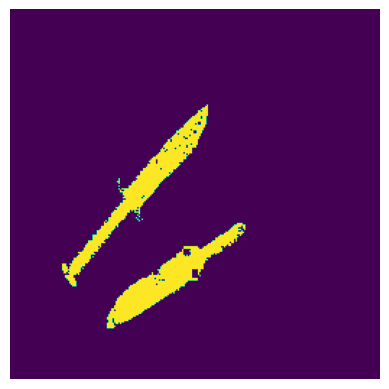

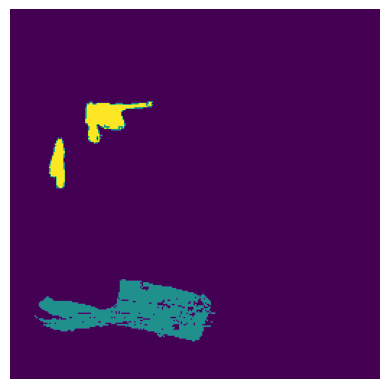

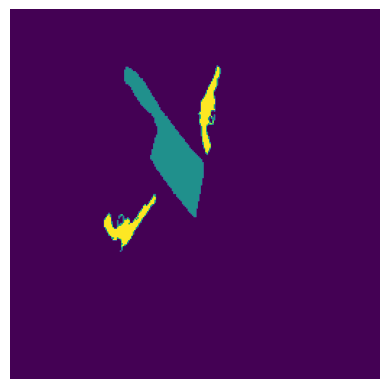

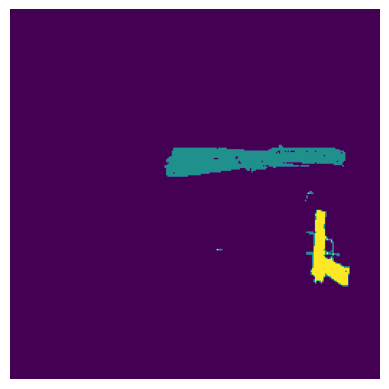

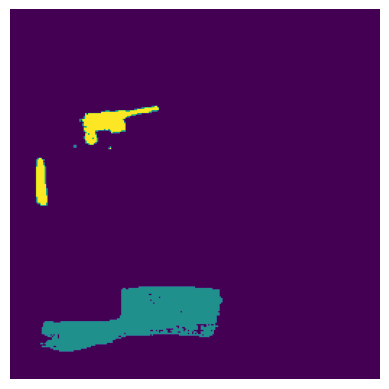

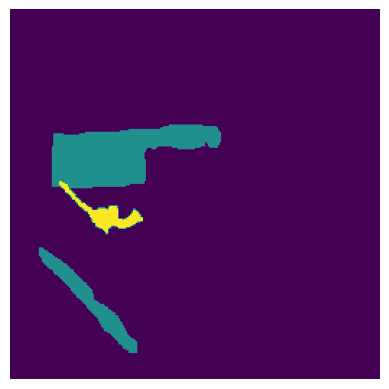

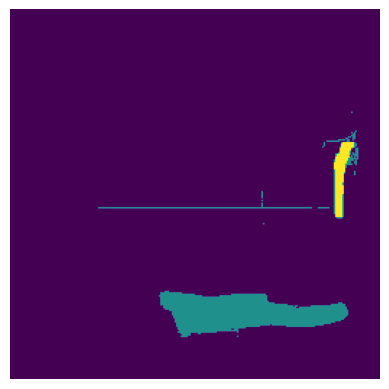

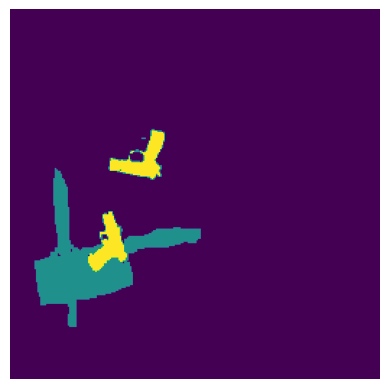

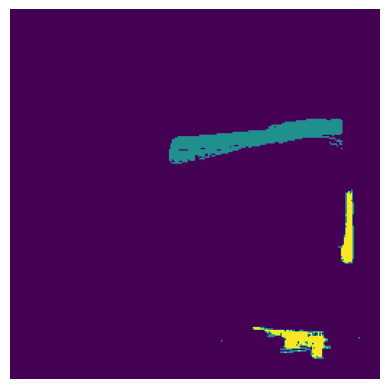

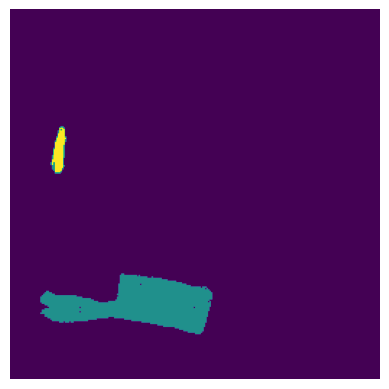

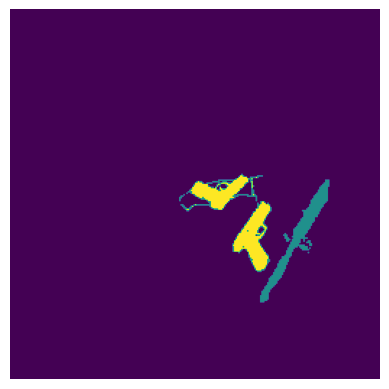

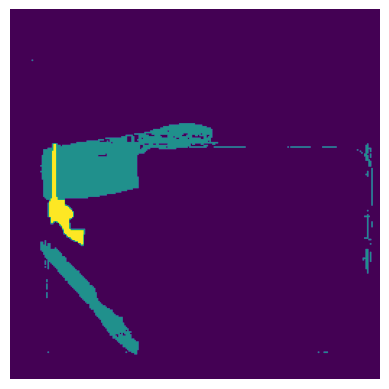

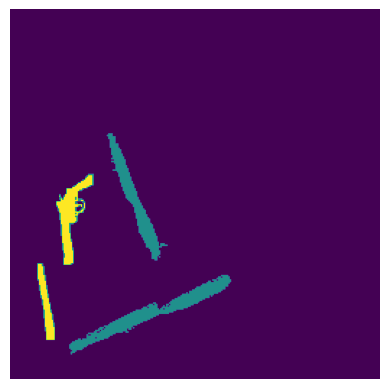

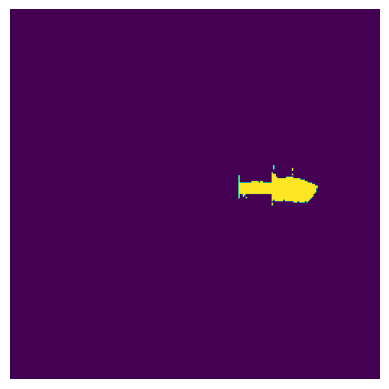

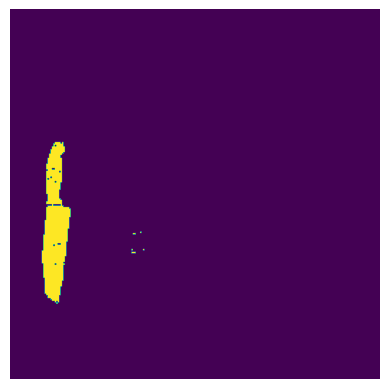

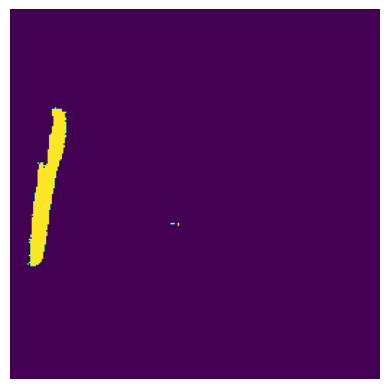

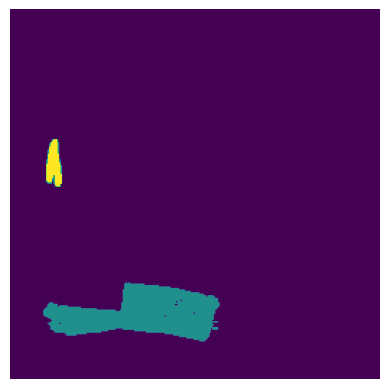

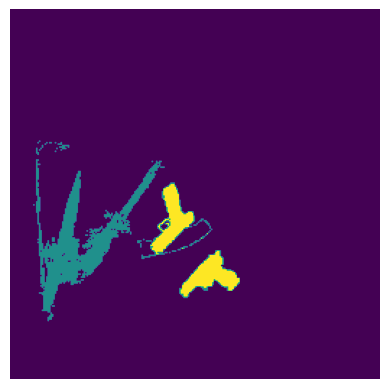

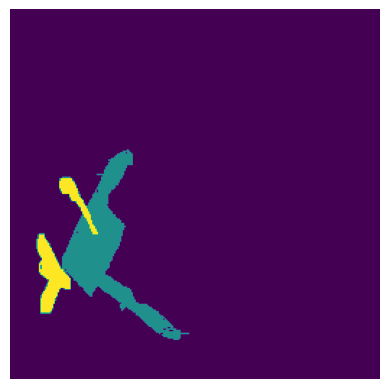

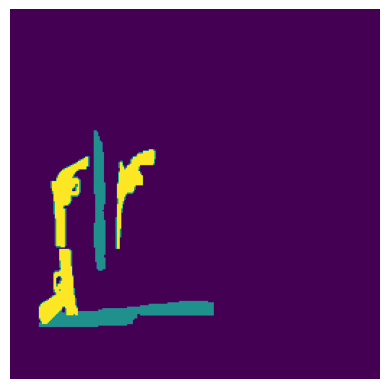

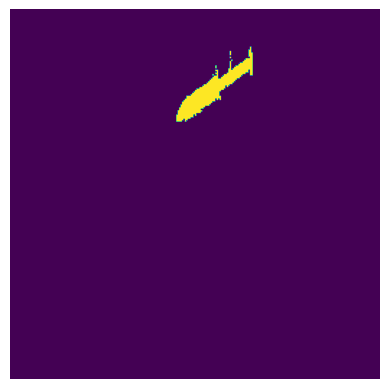

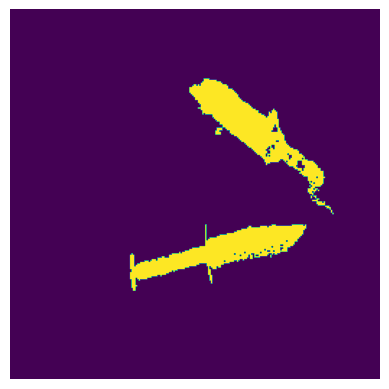

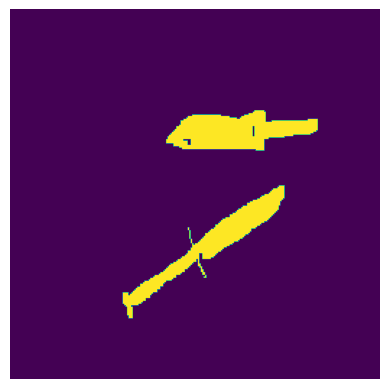

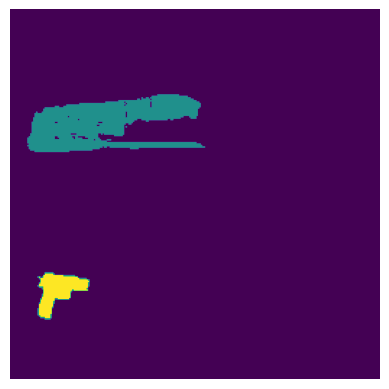

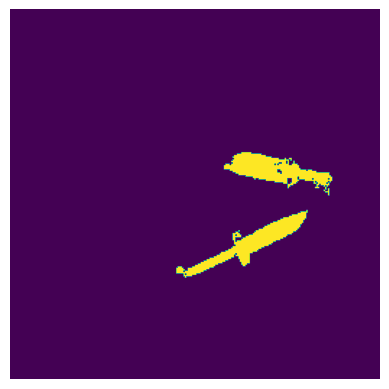

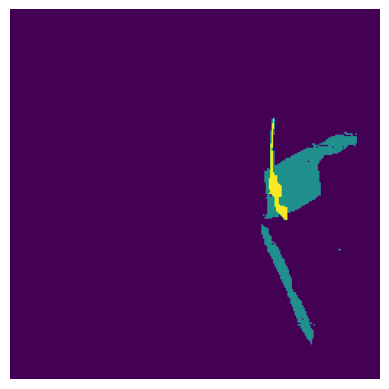

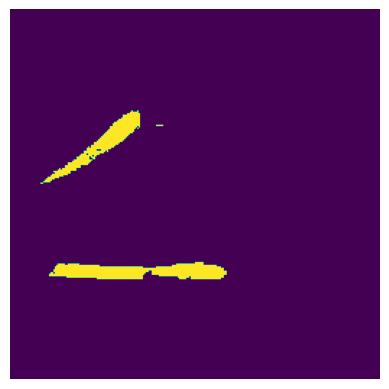

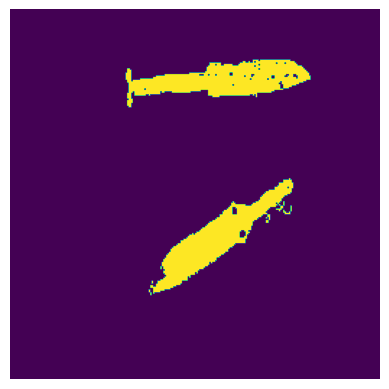

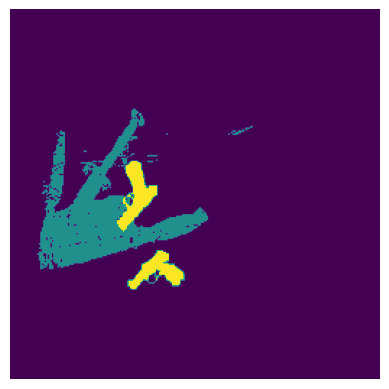

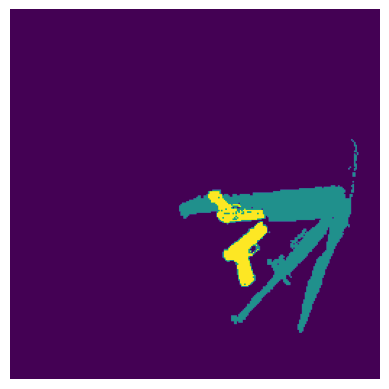

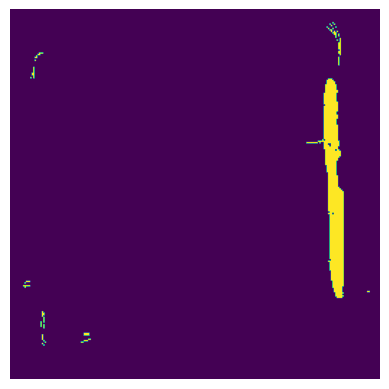

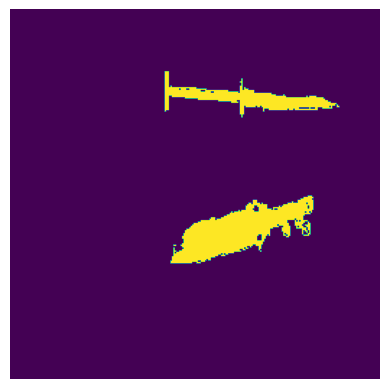

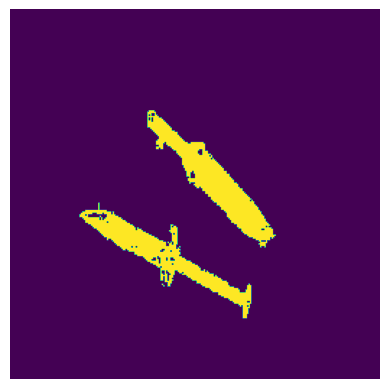

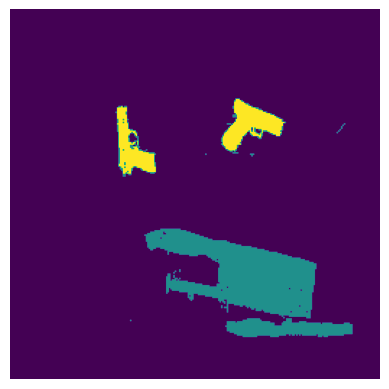

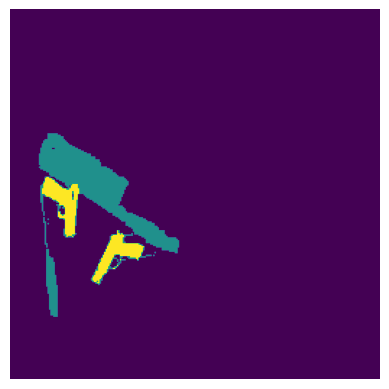

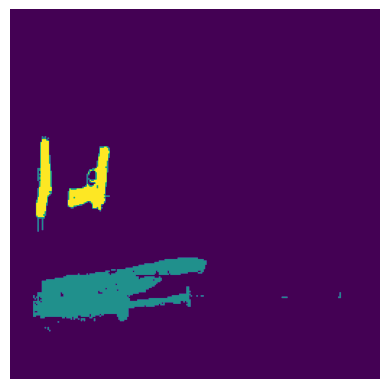

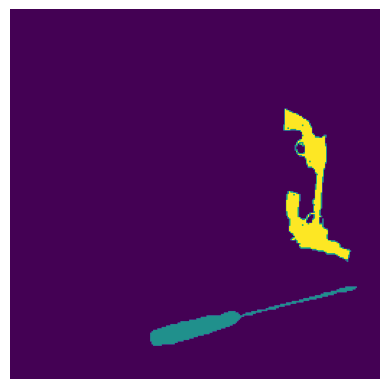

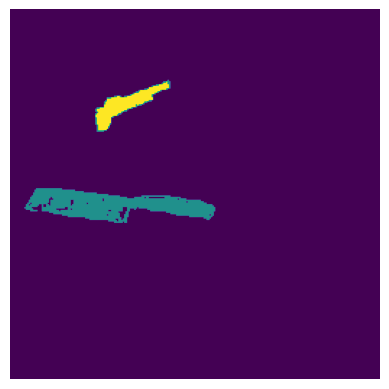

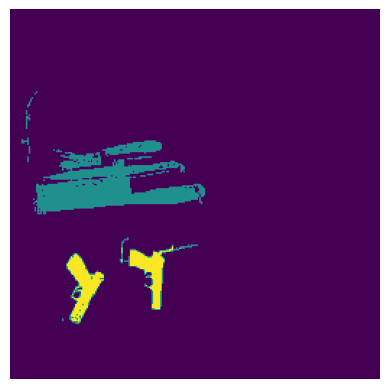

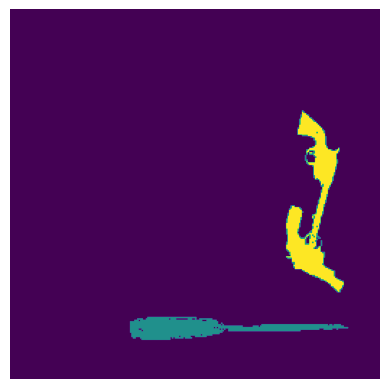

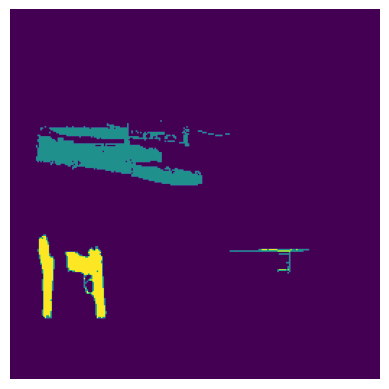

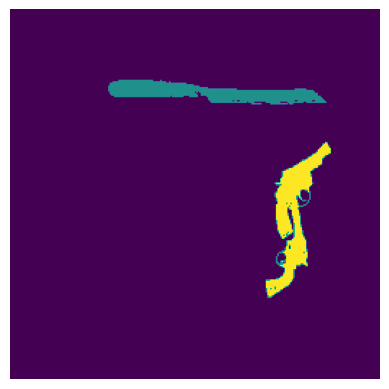

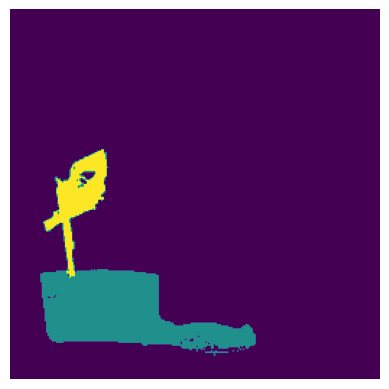

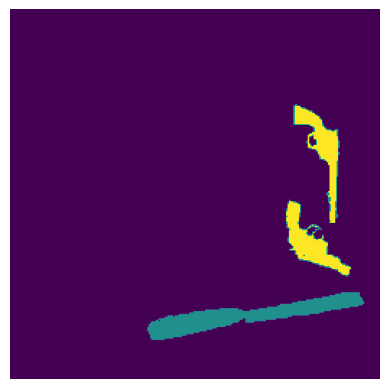

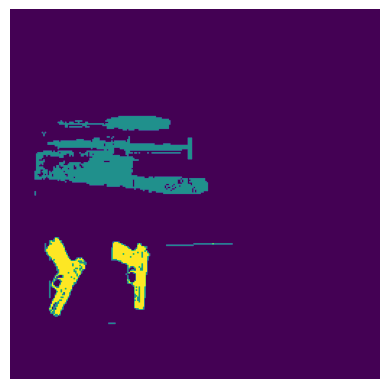

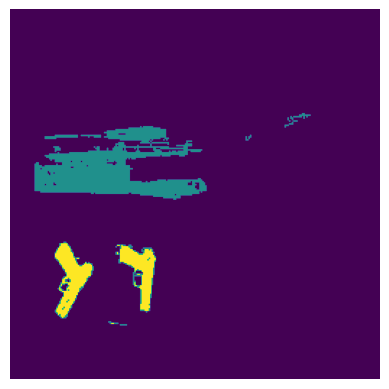

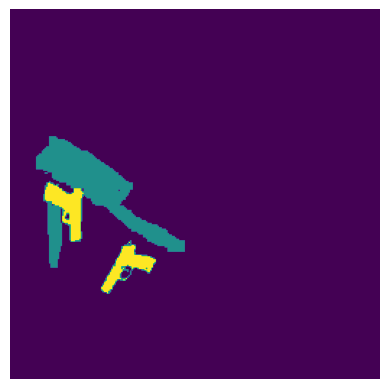

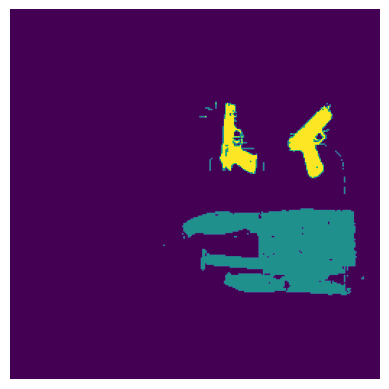

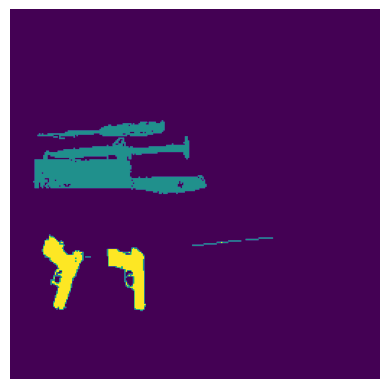

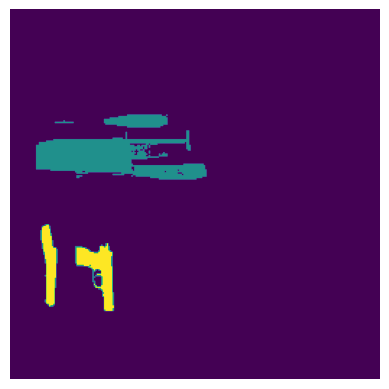

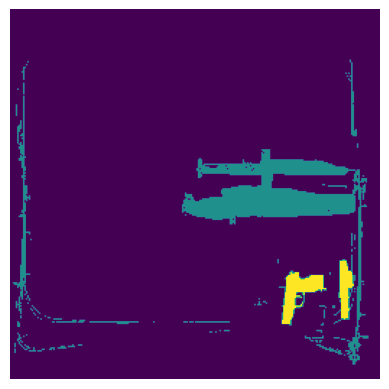

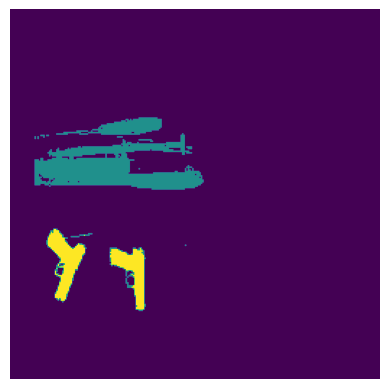

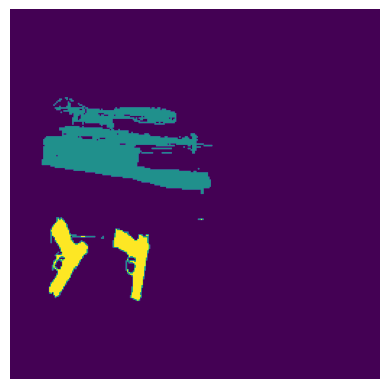

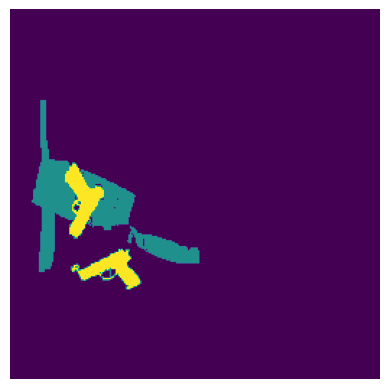

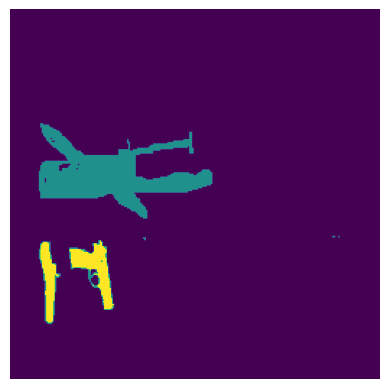

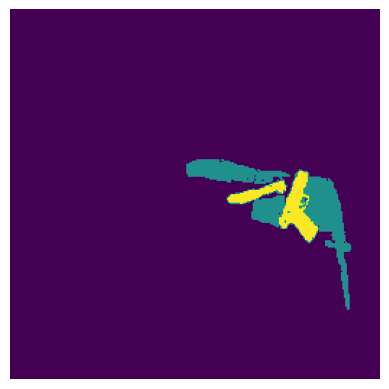

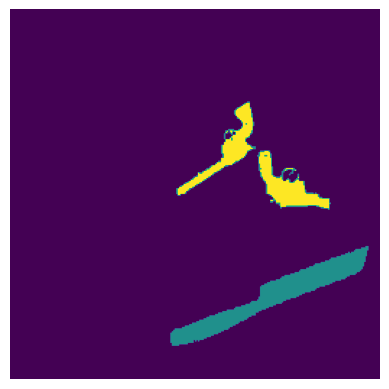

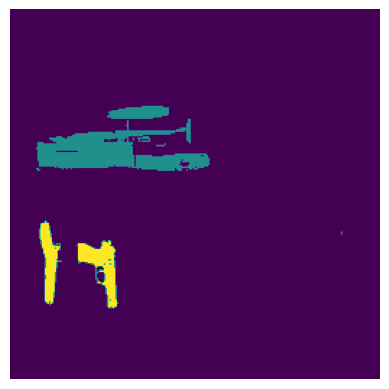

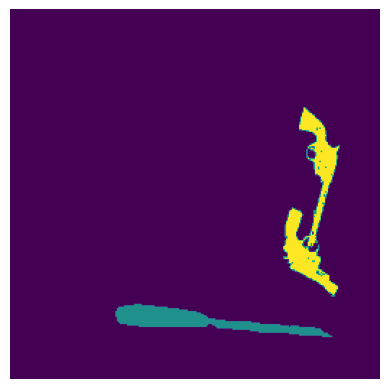

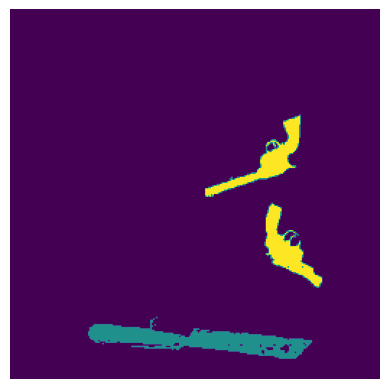

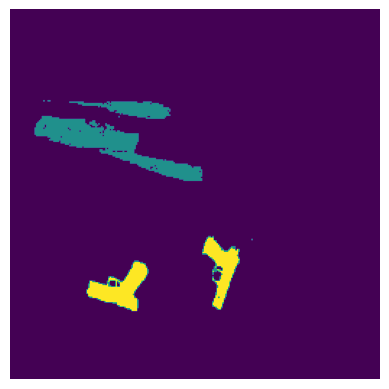

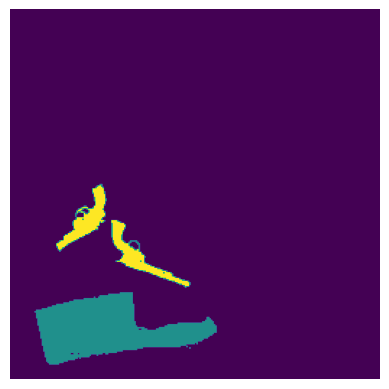

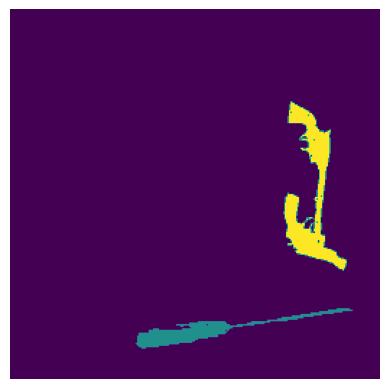

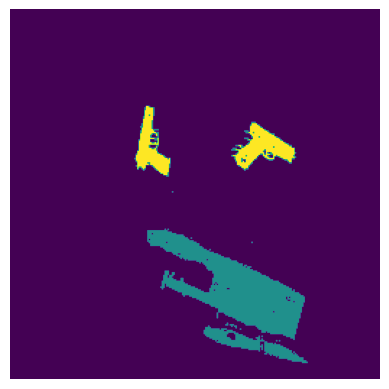

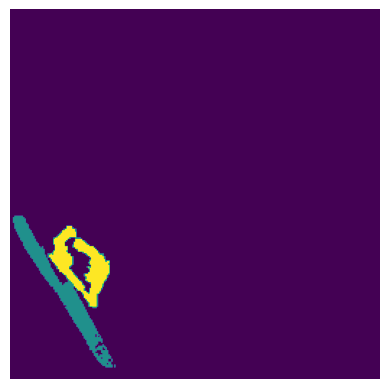

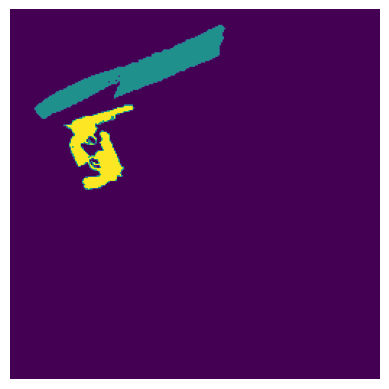

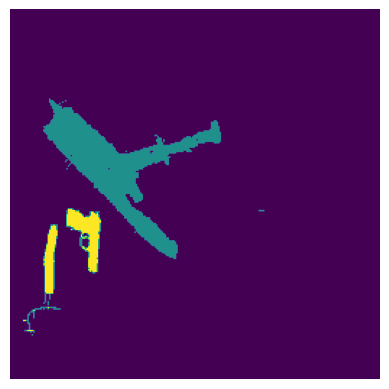

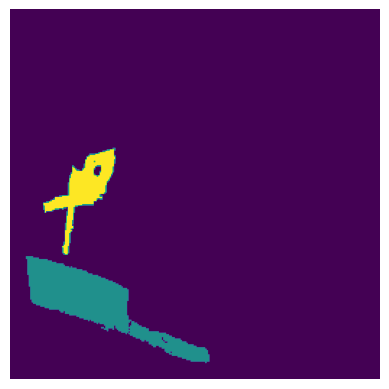

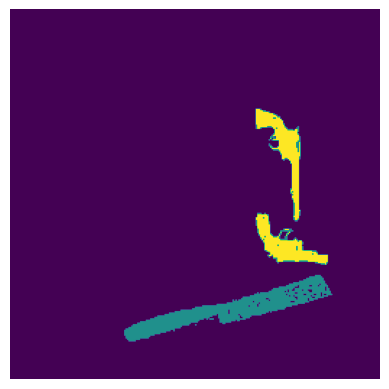

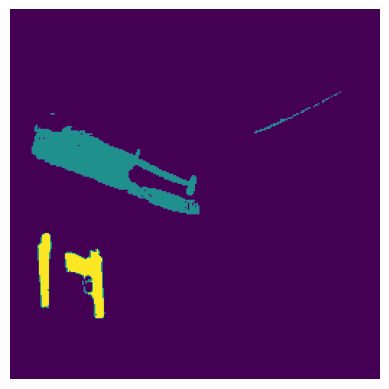

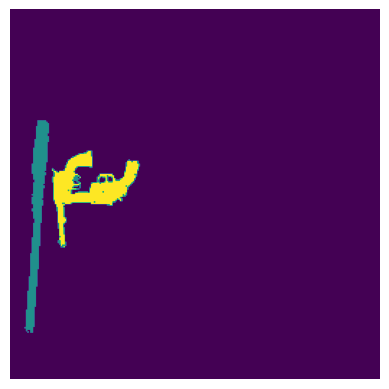

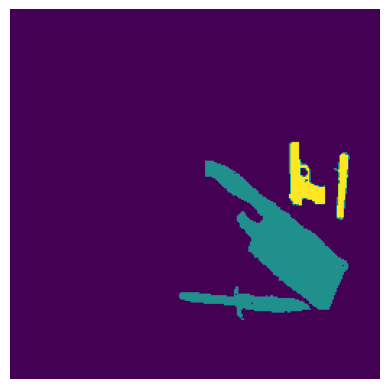

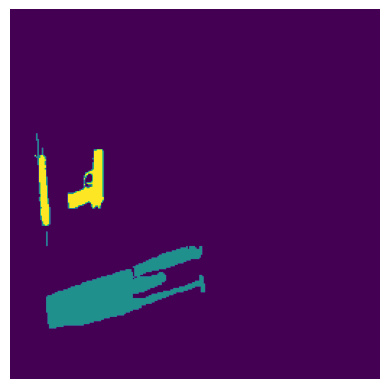

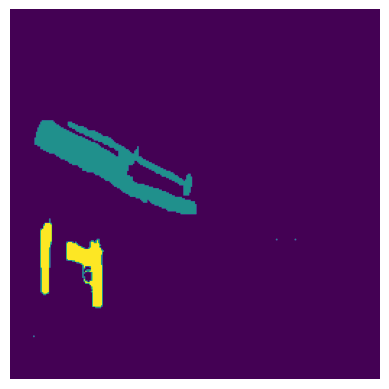

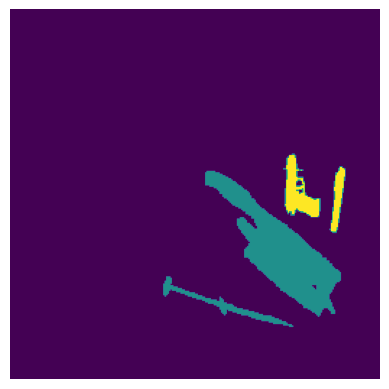

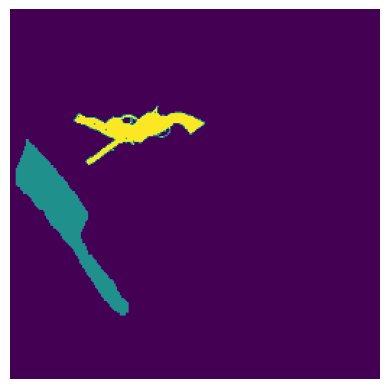

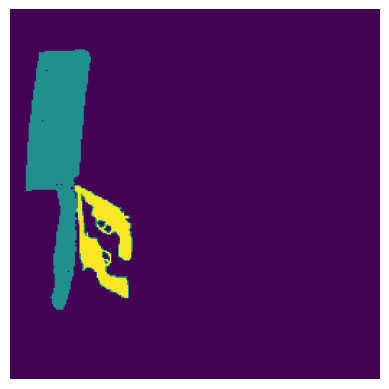

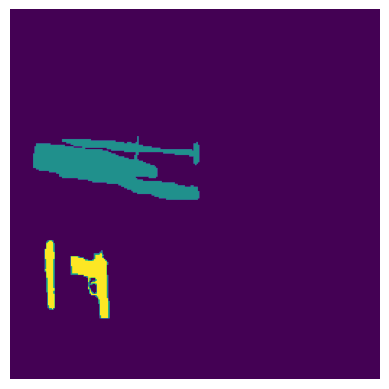

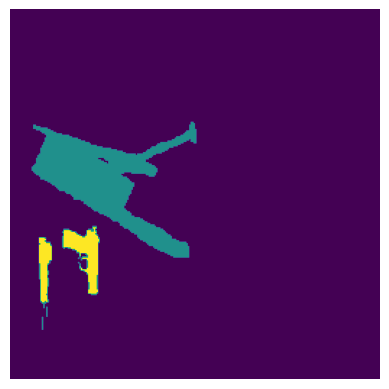

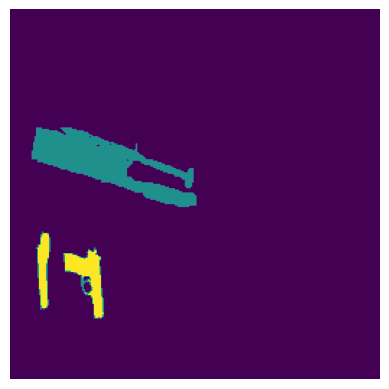

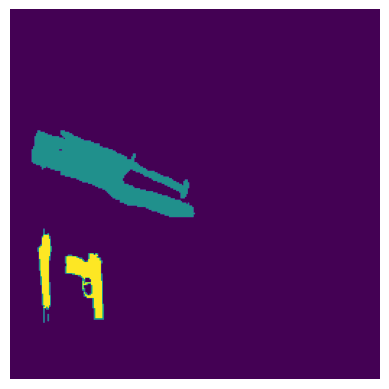

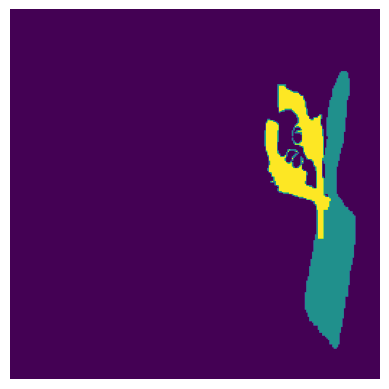

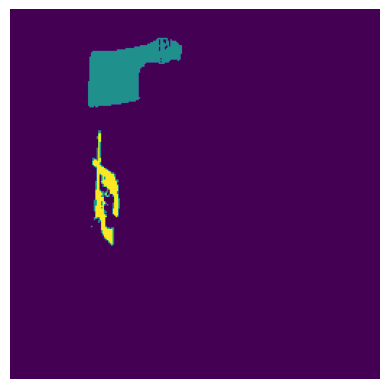

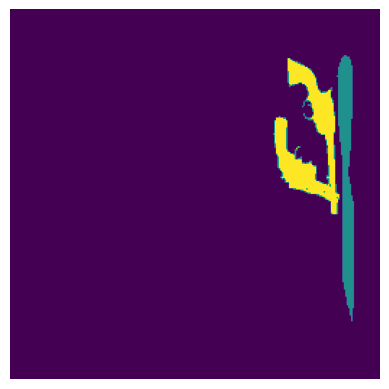

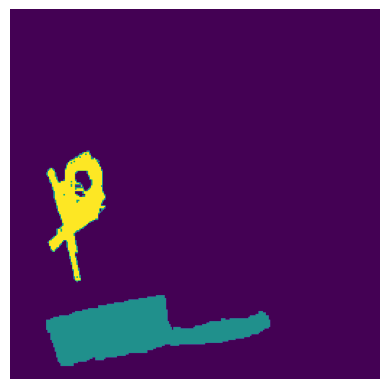

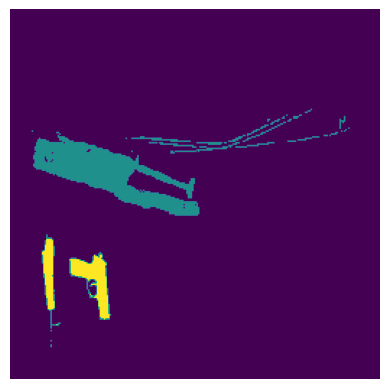

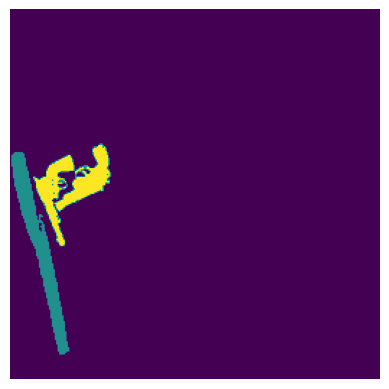

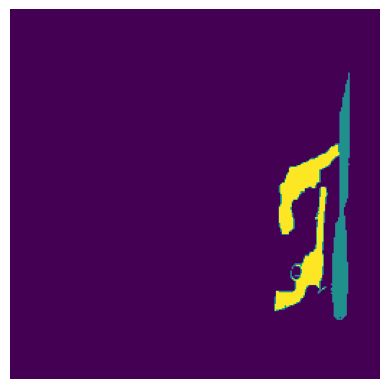

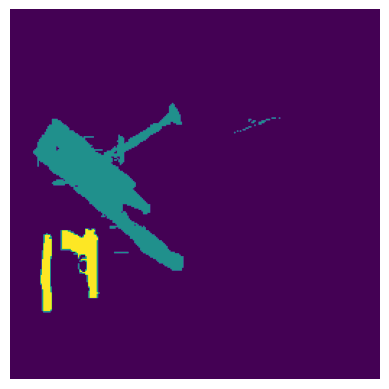

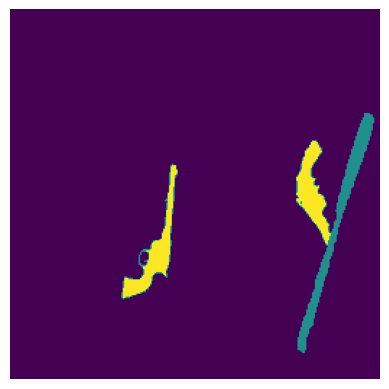

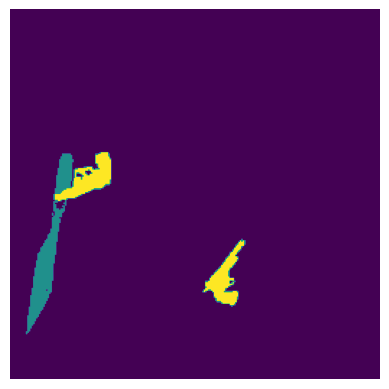

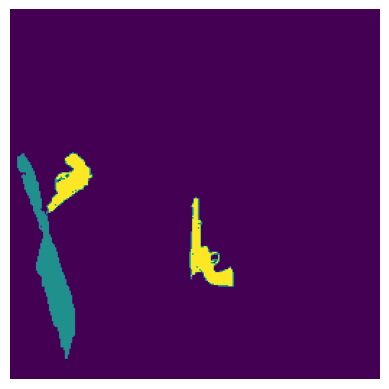

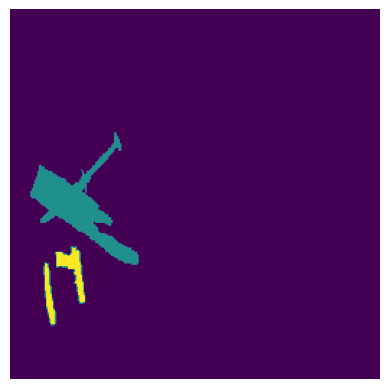

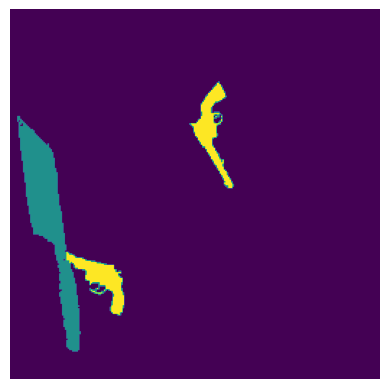

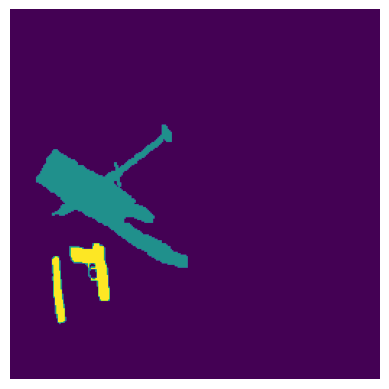

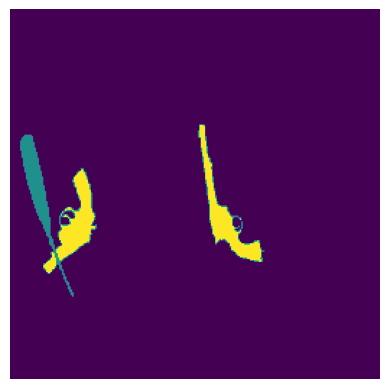

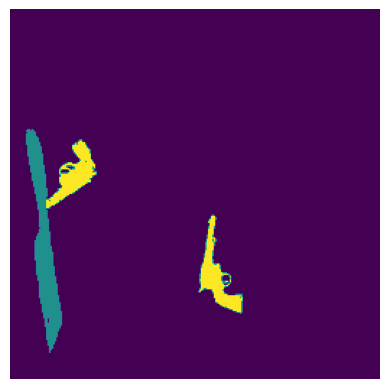

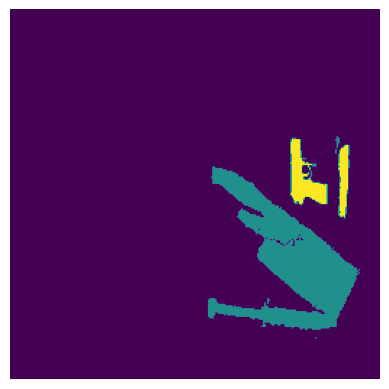

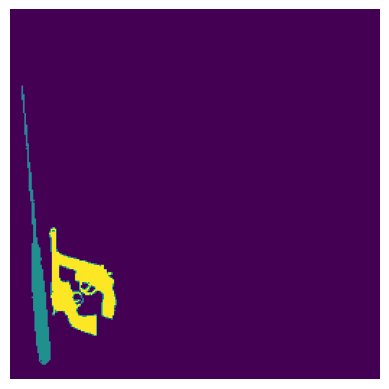

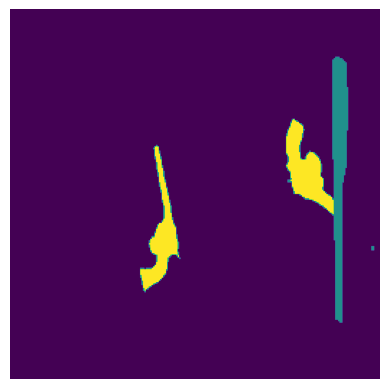

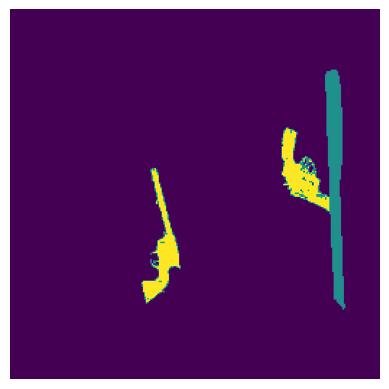

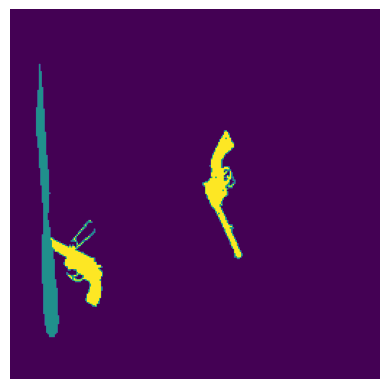

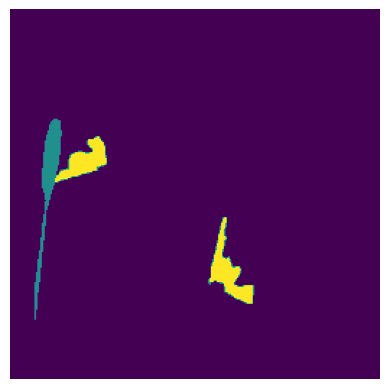

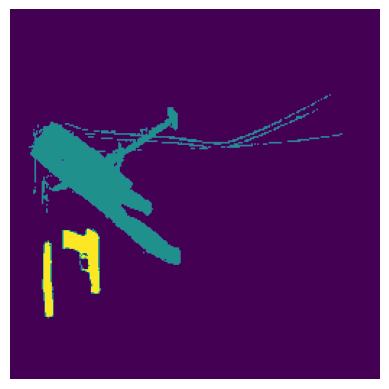

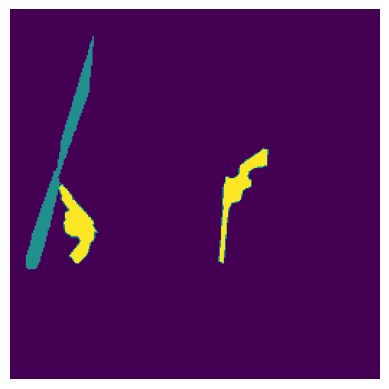

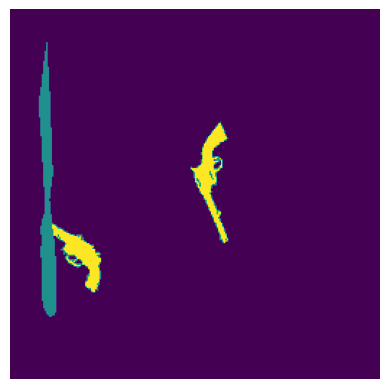

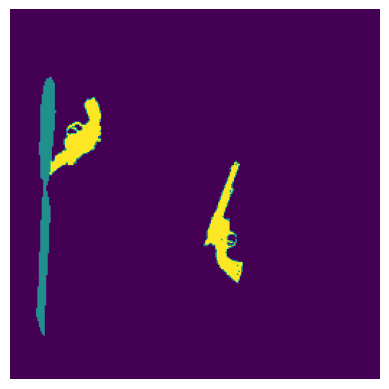

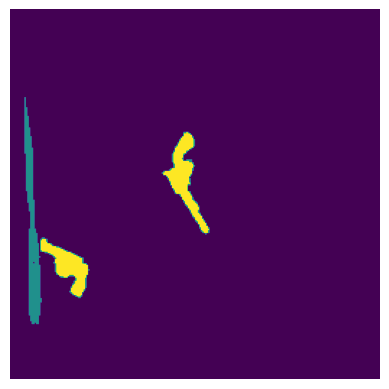

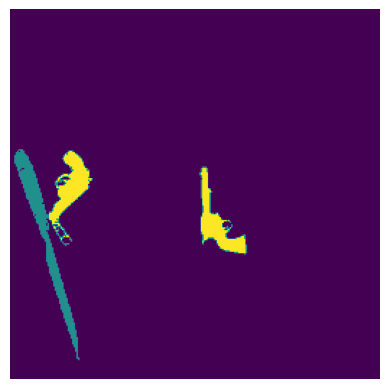

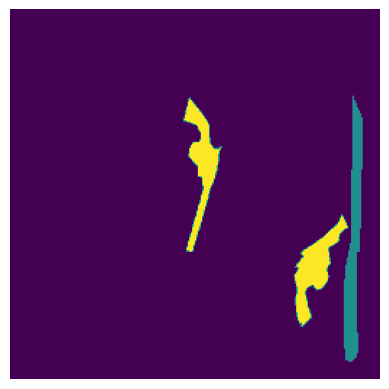

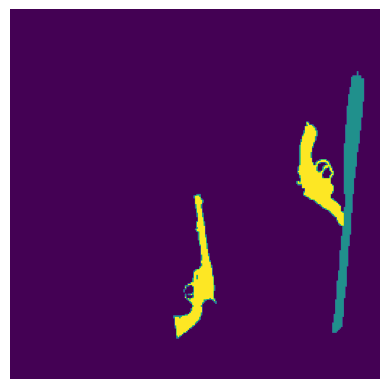

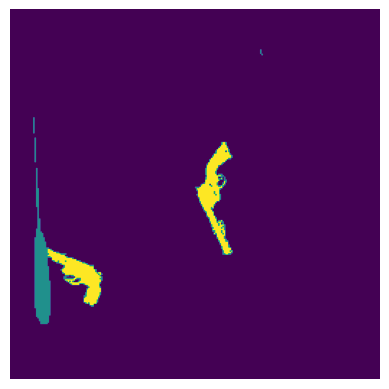

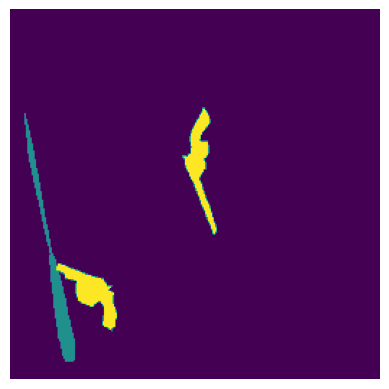

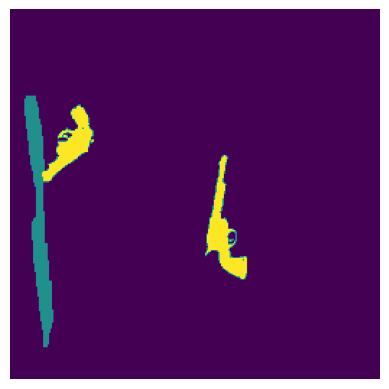

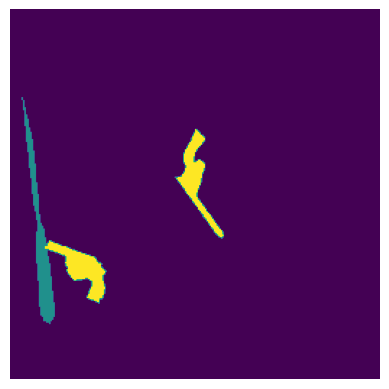

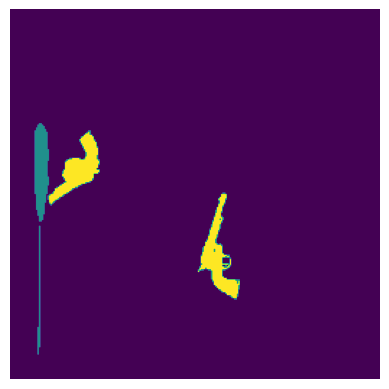

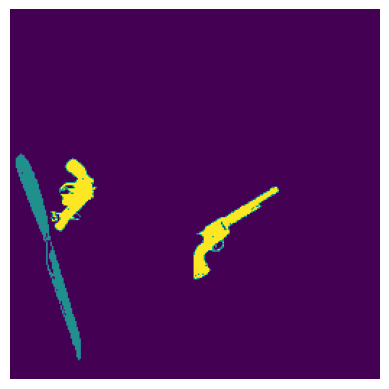

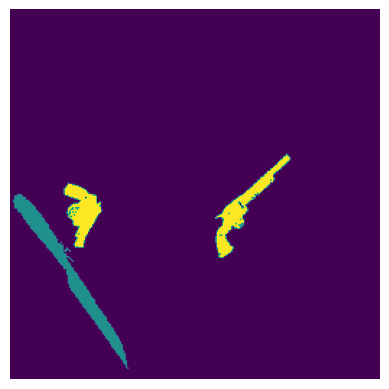

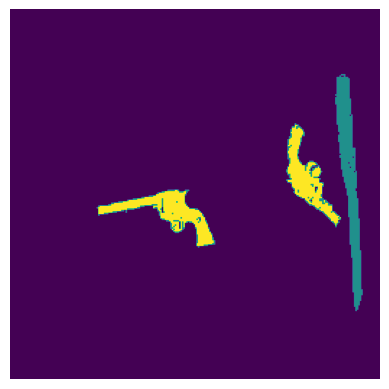

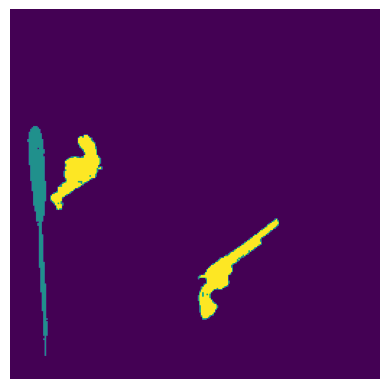

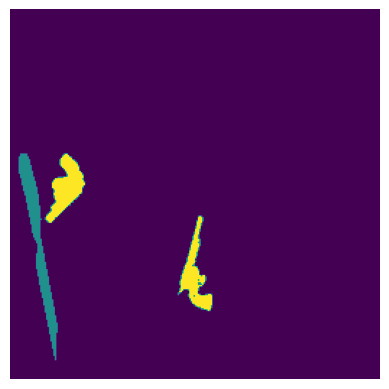

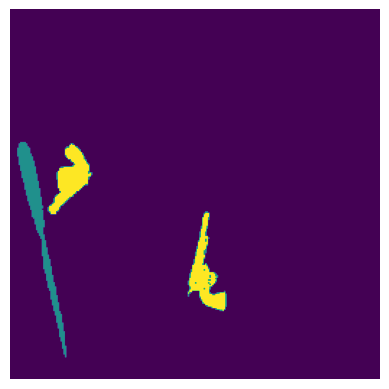

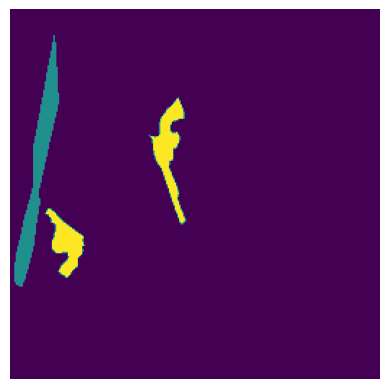

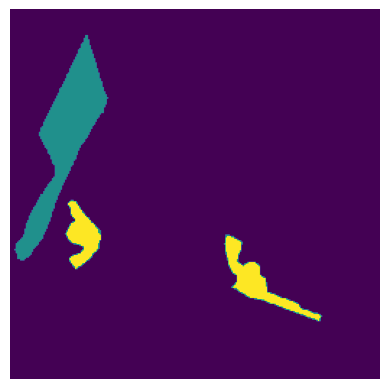

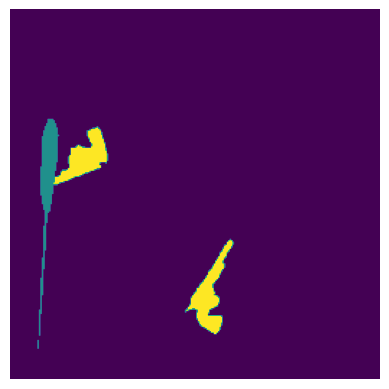

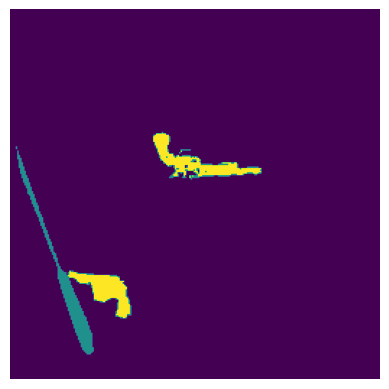

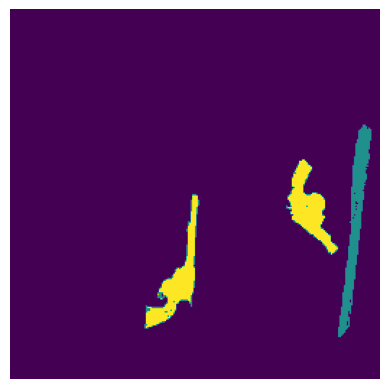

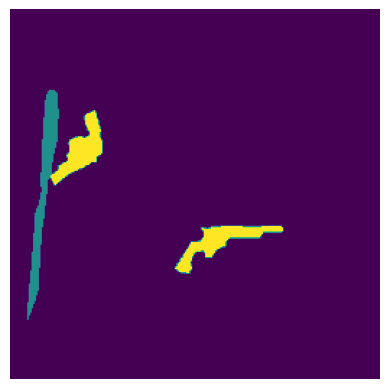

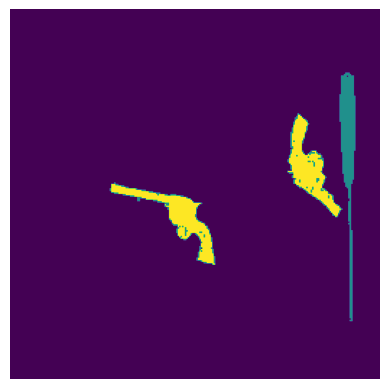

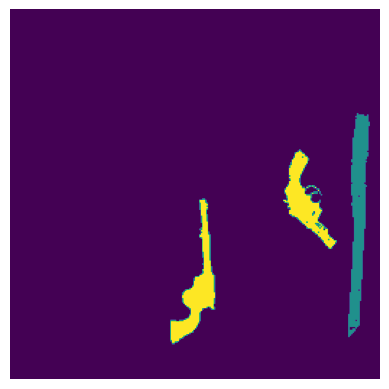

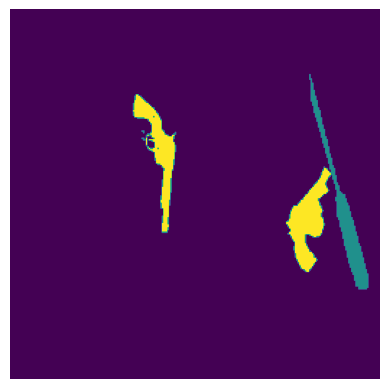

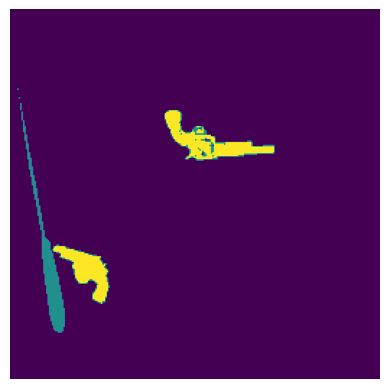

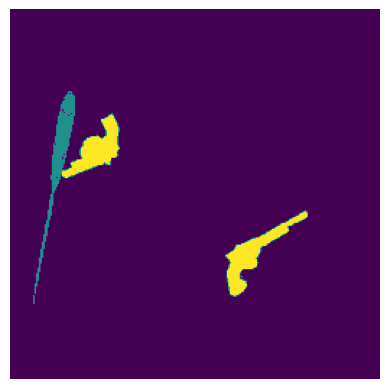

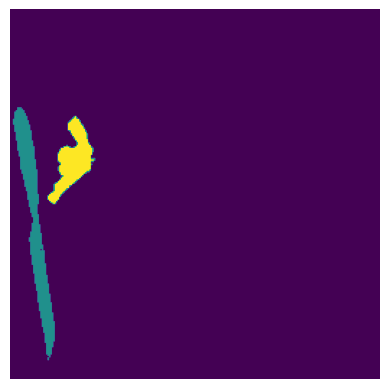

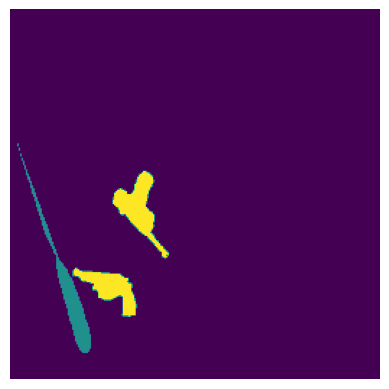

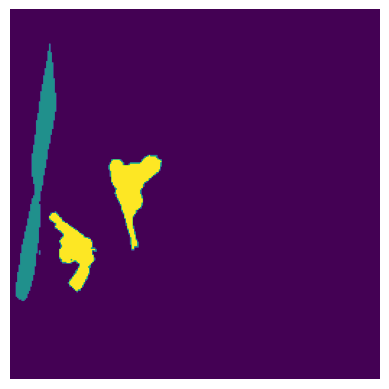

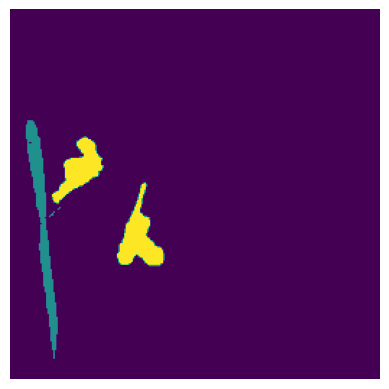

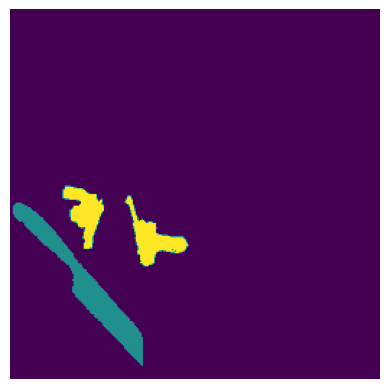

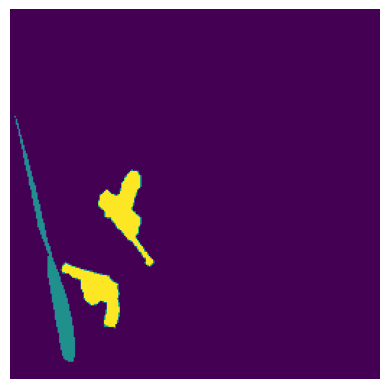

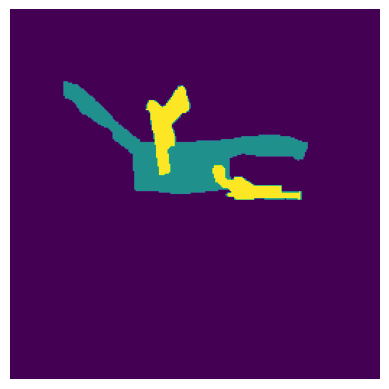

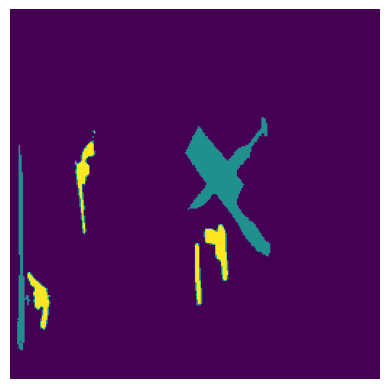

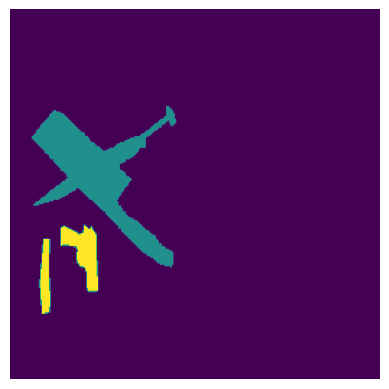

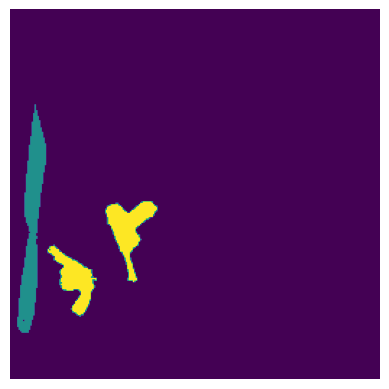

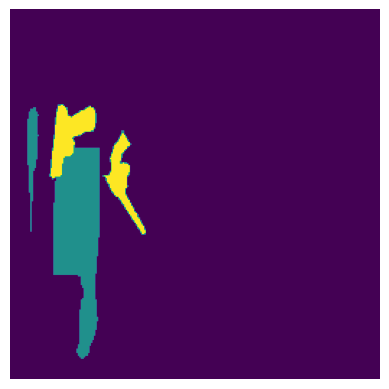

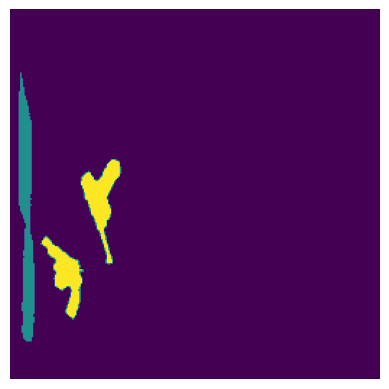

In [ ]:
images = []
labels = []

count=1;
for image_file in os.listdir(image_dir):
    image_path = os.path.join(image_dir, image_file)
    #sorted(image_file_names)
    image = np.array(((Image.open(image_path).resize([256 ,256],resample=Image.HAMMING)).convert("RGB")),dtype=np.float32)
    #image = np.array(((Image.open(image_path).resize([256 ,256],resample=Image.HAMMING)).convert("RGB")))
    image = np.moveaxis(image, -1, 0) ####
    ##image=torch.from_numpy(image).type(torch.LongTensor)
    images.append(image)
    label_file = image_file.replace(".tif", ".png")  # Assuming label files have the same name but with a different extension
    label_path = os.path.join(label_dir, label_file)
    label = (Image.open(label_path).resize([256 ,256],resample=Image.HAMMING)).convert("RGB")
    #label.sh
    mask_gray=label.convert("L")
   ## mask_gray = np.asarray(mask_gray, dtype=np.uint8)
    mask_gray = np.asarray(mask_gray)
    mask_gray = np.copy(np.asarray(mask_gray))
    plt.imshow(mask_gray)
    plt.axis('off')  # Optional: Turn off axis labels and ticks
    plt.show()
    mask_gray=np.array(mask_gray)
  ##  mask_gray=torch.from_numpy(mask_gray).type(torch.LongTensor)
   ## mask_gray=torch.from_numpy(mask_gray).type(torch.LongTensor)
    labels.append(mask_gray)
images = np.array(images)
labels = np.array(labels)


In [ ]:
images = np.array(images)
labels = np.array(labels)

In [ ]:
print(np.shape(images),np.shape(labels))

(168, 3, 256, 256) (168, 256, 256)


In [ ]:
dataset_dict = {'pixel_values': images, 'labels':labels}

In [ ]:
dataset = datasets.Dataset.from_dict(dataset_dict)
dataset.set_format(type='numpy', columns=['pixel_values','labels'])

In [ ]:
dataset[0]

{'pixel_values': array([[[255., 255., 255., ..., 255., 255., 255.],
         [255., 255., 255., ..., 255., 255., 255.],
         [255., 255., 255., ..., 255., 255., 255.],
         ...,
         [255., 255., 255., ..., 255., 255., 255.],
         [255., 255., 255., ..., 255., 255., 255.],
         [255., 255., 255., ..., 255., 255., 255.]],
 
        [[255., 255., 255., ..., 255., 255., 255.],
         [255., 255., 255., ..., 255., 255., 255.],
         [255., 255., 255., ..., 255., 255., 255.],
         ...,
         [255., 255., 255., ..., 255., 255., 255.],
         [255., 255., 255., ..., 255., 255., 255.],
         [255., 255., 255., ..., 255., 255., 255.]],
 
        [[255., 255., 255., ..., 255., 255., 255.],
         [255., 255., 255., ..., 255., 255., 255.],
         [255., 255., 255., ..., 255., 255., 255.],
         ...,
         [255., 255., 255., ..., 255., 255., 255.],
         [255., 255., 255., ..., 255., 255., 255.],
         [255., 255., 255., ..., 255., 255., 255.]]]

In [ ]:
print(labels.max())

2


In [ ]:
dataset.features

{'pixel_values': Sequence(feature=Sequence(feature=Sequence(feature=Value(dtype='float32', id=None), length=-1, id=None), length=-1, id=None), length=-1, id=None),
 'labels': Sequence(feature=Sequence(feature=Value(dtype='uint8', id=None), length=-1, id=None), length=-1, id=None)}

In [ ]:
print(dataset)

Dataset({
    features: ['pixel_values', 'labels'],
    num_rows: 168
})


In [ ]:
a= dataset[0]
a.keys()
print(np.shape(a['pixel_values']))
print(np.shape(a['labels']))
print(type(a['pixel_values']))
print(type(a['labels']))
print(type(a))

(3, 256, 256)
(256, 256)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'dict'>


In [ ]:
dataset[0]['labels'].dtype
dataset[0]['pixel_values'].dtype

dtype('float32')

In [ ]:
!pip install datasets
from datasets import Dataset, DatasetDict # Import DatasetDict
from torchvision.transforms import ColorJitter
from transformers import SegformerFeatureExtractor
from sklearn.model_selection import train_test_split
import numpy as np
import copy

feature_extractor = SegformerFeatureExtractor()
jitter = ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25, hue=0.1)

def train_transforms(example_batch):
    print("trace1")
    images = [jitter(x) for x in example_batch['pixel_values']]
    labels = [x for x in example_batch['labels']]
    inputs = feature_extractor(images, labels)
    display("exec")
    print(inputs.size)
    inputs = np.array(inputs)
    return inputs

def val_transforms(example_batch):
    images = [x for x in example_batch['pixel_values']]
    labels = [x for x in example_batch['labels']]
    inputs = feature_extractor(images, labels)
    inputs = np.array(inputs)
    return inputs

# Split dataset into train and test using DatasetDict
dataset_dict = DatasetDict({
    'train': Dataset.from_dict(dataset[:int(len(dataset)*0.8)]),
    'test': Dataset.from_dict(dataset[int(len(dataset)*0.8):])
})

# Set transforms
# Use the Dataset objects from dataset_dict, not the original dictionaries
train_ds = copy.deepcopy(dataset_dict['train'])
test_ds = copy.deepcopy(dataset_dict['test'])

train_ds.set_transform(train_transforms)
test_ds.set_transform(val_transforms)

/usr/local/lib/python3.10/dist-packages/transformers/models/segformer/feature_extraction_segformer.py:28: FutureWarning: The class SegformerFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use SegformerImageProcessor instead.
  warnings.warn(


In [ ]:
dataset[0]['labels'].dtype

dtype('int64')

In [ ]:
train_ds.set_format(type='numpy', columns=['pixel_values', 'labels'])
test_ds.set_format(type='numpy', columns=['pixel_values', 'labels'])

In [ ]:
train_ds.features

{'pixel_values': Sequence(feature=Sequence(feature=Sequence(feature=Value(dtype='float32', id=None), length=-1, id=None), length=-1, id=None), length=-1, id=None),
 'labels': Sequence(feature=Sequence(feature=Value(dtype='int64', id=None), length=-1, id=None), length=-1, id=None)}

In [ ]:
train_ds

Dataset({
    features: ['pixel_values', 'labels'],
    num_rows: 134
})

In [ ]:
test_ds.features

{'pixel_values': Sequence(feature=Sequence(feature=Sequence(feature=Value(dtype='float32', id=None), length=-1, id=None), length=-1, id=None), length=-1, id=None),
 'labels': Sequence(feature=Sequence(feature=Value(dtype='int64', id=None), length=-1, id=None), length=-1, id=None)}

In [ ]:
test_ds

Dataset({
    features: ['pixel_values', 'labels'],
    num_rows: 34
})

In [ ]:
from transformers import SegformerForSemanticSegmentation

pretrained_model_name = "nvidia/mit-b2"
model = SegformerForSemanticSegmentation.from_pretrained(
    pretrained_model_name,
    id2label=id2label,
    label2id=label2id
)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/70.0k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/99.0M [00:00<?, ?B/s]

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b2 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import TrainingArguments

epochs = 50
lr = 0.00006
batch_size = 6

hub_model_id = "segformer-b2-finetuned-segments-sidewalksmix"

training_args = TrainingArguments(
    "segformer-b2-finetuned-segments-sidewalksmix",
    learning_rate=lr,
    num_train_epochs=epochs,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    save_total_limit=3,
    evaluation_strategy="steps",
    save_strategy="steps",
    save_steps=20,
    eval_steps=20,
    logging_steps=1,
    eval_accumulation_steps=5,
    load_best_model_at_end=True,
    push_to_hub=True,
    hub_model_id=hub_model_id,
    hub_strategy="end",
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
print(images)
print(labels)

[[[[255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]
   ...
   [255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]]

  [[255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]
   ...
   [255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]]

  [[255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]
   ...
   [255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]]]


 [[[255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]
   ...
   [255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]]

  [[255. 255. 255. ... 255

In [ ]:
import torch
from torch import nn
import evaluate

print("trace3")
metric = evaluate.load("mean_iou")

def compute_metrics(eval_pred):
  with torch.no_grad():
    print("trace1")
    logits, labels = eval_pred
    logits_tensor = torch.from_numpy(logits)
    print("trace2")
    # scale the logits to the size of the label
    logits_tensor = nn.functional.interpolate(
        logits_tensor,
        size=labels.shape[-2:],
        mode="bilinear",
        align_corners=False,
    ).argmax(dim=1)

    pred_labels = logits_tensor.detach().cpu().numpy()
    # currently using _compute instead of compute
    # see this issue for more info: https://github.com/huggingface/evaluate/pull/328#issuecomment-1286866576
    metrics = metric._compute(
            predictions=pred_labels,
            references=labels,
            num_labels=len(id2label),
            ignore_index=255,
            reduce_labels=feature_extractor.do_reduce_labels,
        )

    # add per category metrics as individual key-value pairs
    per_category_accuracy = metrics.pop("per_category_accuracy").tolist()
    per_category_iou = metrics.pop("per_category_iou").tolist()

    metrics.update({f"accuracy_{id2label[i]}": v for i, v in enumerate(per_category_accuracy)})
    metrics.update({f"iou_{id2label[i]}": v for i, v in enumerate(per_category_iou)})

    return metrics

trace3


In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
image = train_ds

In [ ]:
image.shape

(134, 2)

In [ ]:
image = test_ds
image.shape

(34, 2)

In [ ]:
train_ds.features

{'pixel_values': Sequence(feature=Sequence(feature=Sequence(feature=Value(dtype='float32', id=None), length=-1, id=None), length=-1, id=None), length=-1, id=None),
 'labels': Sequence(feature=Sequence(feature=Value(dtype='int64', id=None), length=-1, id=None), length=-1, id=None)}

In [ ]:
type(train_ds)

datasets.arrow_dataset.Dataset

In [ ]:
datasets.arrow_dataset.Dataset

datasets.arrow_dataset.Dataset

In [ ]:
from transformers import Trainer, TrainerCallback

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
    callbacks=[TrainerCallback()],
)

In [ ]:
from transformers import TrainerCallback
from transformers import Trainer

checkpoint_dir='content/drive/MyDrive/Data-15/checkpoint4/'
class ModelCheckpointCallback(TrainerCallback):
    def __init__(self, dirpath, save_top_k=1, monitor="val_loss"):
        self.dirpath = dirpath
        self.save_top_k = save_top_k
        self.monitor = monitor

    def on_epoch_end(self, args, state, control, **kwargs):
        # Save the model checkpoint after each epoch
        print("model saved1")
       # if  state.epoch % args.save_steps == 0:
            # Use your preferred method to save the model
        model.save_pretrained(self.dirpath)
        print("model saved2")



        return control

pretrained_model_name = "nvidia/mit-b2"
model = SegformerForSemanticSegmentation.from_pretrained(
    pretrained_model_name,
    id2label=id2label,
    label2id=label2id
)

# Load the saved model checkpoint
checkpoint_dir = '/content/drive/MyDrive/Data-15/checkpoint4'  # Specify the directory where the checkpoint is saved
#model = SegformerForSemanticSegmentation.from_pretrained(checkpoint_dir)

checkpoint_callback = ModelCheckpointCallback(dirpath='/content/drive/MyDrive/Data-15/checkpoint4', save_top_k=1, monitor="val_loss")
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
    callbacks=[checkpoint_callback],
)



Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b2 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Step,Training Loss,Validation Loss,Mean Iou,Mean Accuracy,Overall Accuracy,Accuracy Bkg,Accuracy Knife,Accuracy Gun,Iou Bkg,Iou Knife,Iou Gun
20,0.591500,0.722114,0.505919,0.630638,0.956976,0.979566,0.558832,0.353517,0.964322,0.309012,0.244422
40,0.317000,0.411540,0.626585,0.742870,0.971657,0.987566,0.667930,0.573115,0.975795,0.441409,0.462552
60,0.135400,0.169994,0.708100,0.812129,0.979601,0.991338,0.725747,0.719302,0.982675,0.541259,0.600366


trace1
trace2
model saved1
model saved2
trace1
trace2
model saved1
model saved2
trace1
trace2
model saved1
model saved2


Step,Training Loss,Validation Loss,Mean Iou,Mean Accuracy,Overall Accuracy,Accuracy Bkg,Accuracy Knife,Accuracy Gun,Iou Bkg,Iou Knife,Iou Gun
20,0.591500,0.722114,0.505919,0.630638,0.956976,0.979566,0.558832,0.353517,0.964322,0.309012,0.244422
40,0.317000,0.411540,0.626585,0.742870,0.971657,0.987566,0.667930,0.573115,0.975795,0.441409,0.462552
60,0.135400,0.169994,0.708100,0.812129,0.979601,0.991338,0.725747,0.719302,0.982675,0.541259,0.600366
80,0.096800,0.103682,0.725808,0.826816,0.981285,0.992044,0.769912,0.718492,0.984469,0.565753,0.627202
100,0.082800,0.073142,0.759034,0.862274,0.983332,0.991840,0.791511,0.803470,0.985574,0.608841,0.682687
120,0.058100,0.063446,0.763294,0.809835,0.984952,0.997320,0.686899,0.745284,0.986293,0.619688,0.683902
140,0.069100,0.055776,0.747006,0.775573,0.984276,0.998942,0.654414,0.673363,0.985429,0.605290,0.650298
160,0.043800,0.048729,0.785121,0.853201,0.986028,0.995422,0.755738,0.808443,0.987621,0.644551,0.723191
180,0.051600,0.045885,0.786622,0.847064,0.986412,0.996289,0.736788,0.808114,0.988059,0.642232,0.729574
200,0.046100,0.043801,0.790535,0.843011,0.986845,0.996984,0.748603,0.783447,0.988399,0.657205,0.725999


trace1
trace2
model saved1
model saved2
trace1
trace2
model saved1
model saved2
trace1
trace2
model saved1
model saved2
trace1
trace2
trace1
trace2
model saved1
model saved2
trace1
trace2
model saved1
model saved2
trace1
trace2
model saved1
model saved2
trace1
trace2
model saved1
model saved2
trace1
trace2
model saved1
model saved2
trace1
trace2
model saved1
model saved2
trace1
trace2
model saved1
model saved2
trace1
trace2
trace1
trace2
model saved1
model saved2
trace1
trace2
model saved1
model saved2
trace1
trace2
model saved1
model saved2
trace1
trace2
model saved1
model saved2
trace1
trace2
model saved1
model saved2
trace1
trace2
model saved1
model saved2
trace1
trace2
trace1
trace2
model saved1
model saved2
trace1
trace2
model saved1
model saved2
trace1
trace2
model saved1
model saved2
trace1
trace2
model saved1
model saved2
trace1
trace2
model saved1
model saved2
trace1
trace2
model saved1
model saved2
trace1
trace2
model saved1
model saved2
trace1
trace2
trace1
trace2
model save

TrainOutput(global_step=1150, training_loss=0.05761024068393137, metrics={'train_runtime': 18143.6827, 'train_samples_per_second': 0.369, 'train_steps_per_second': 0.063, 'total_flos': 2.161561487671296e+17, 'train_loss': 0.05761024068393137, 'epoch': 50.0})

In [ ]:
from transformers import SegformerForSemanticSegmentation

pretrained_model_name = "nvidia/mit-b2"

# Instantiate the model
model = SegformerForSemanticSegmentation.from_pretrained(
    pretrained_model_name,
    id2label=id2label,
    label2id=label2id
)

# Load the saved model checkpoint
checkpoint_dir = '/content/drive/MyDrive/Data-15/checkpoint4'  # Specify the directory where the checkpoint is saved
model = SegformerForSemanticSegmentation.from_pretrained(checkpoint_dir)

# Continue training with the loaded model
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=train_ds,
    compute_metrics=compute_metrics,
    callbacks=[checkpoint_callback],
)

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b2 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
trainer.push_to_hub()


training_args.bin:   0%|          | 0.00/5.30k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/Saad287/segformer-b2-finetuned-segments-sidewalksmix/commit/ea34b83bdbbd685b0c1098e69ad79c4df17ffb84', commit_message='End of training', commit_description='', oid='ea34b83bdbbd685b0c1098e69ad79c4df17ffb84', pr_url=None, pr_revision=None, pr_num=None)

Inference

In [ ]:
hf_username='Saad287'
hub_model_id = "segformer-b2-finetuned-segments-sidewalksmix"

In [ ]:
image = test_ds[15]['pixel_values']
gt_seg = test_ds[15]['labels']
image


array([[[255., 255., 255., ..., 255., 255., 255.],
        [255., 255., 255., ..., 255., 255., 255.],
        [255., 255., 255., ..., 255., 255., 255.],
        ...,
        [255., 255., 255., ..., 255., 255., 255.],
        [255., 255., 255., ..., 255., 255., 255.],
        [255., 255., 255., ..., 255., 255., 255.]],

       [[255., 255., 255., ..., 255., 255., 255.],
        [255., 255., 255., ..., 255., 255., 255.],
        [255., 255., 255., ..., 255., 255., 255.],
        ...,
        [255., 255., 255., ..., 255., 255., 255.],
        [255., 255., 255., ..., 255., 255., 255.],
        [255., 255., 255., ..., 255., 255., 255.]],

       [[255., 255., 255., ..., 255., 255., 255.],
        [255., 255., 255., ..., 255., 255., 255.],
        [255., 255., 255., ..., 255., 255., 255.],
        ...,
        [255., 255., 255., ..., 255., 255., 255.],
        [255., 255., 255., ..., 255., 255., 255.],
        [255., 255., 255., ..., 255., 255., 255.]]], dtype=float32)

In [ ]:
image.shape[0]

3

In [ ]:
from torch import nn
sizei=image.shape[1],image.shape[2]
inputs = feature_extractor(images=image, return_tensors="pt")
outputs = model(**inputs)
logits = outputs.logits  # shape (batch_size, num_labels, height/4, width/4)
upsampled_logits = nn.functional.interpolate(
    logits,
    size=sizei, # (height, width)
    mode='bilinear',
    align_corners=False
)
pred_seg = upsampled_logits.argmax(dim=1)[0]

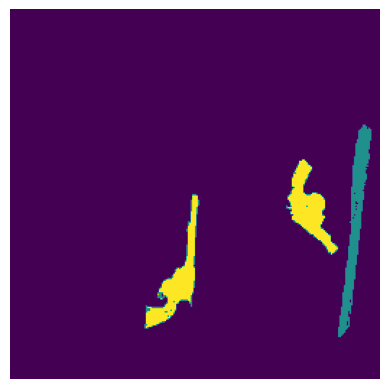

torch.Size([256, 256])

In [ ]:
plt.imshow(gt_seg)
plt.axis('off')  # Optional: Turn off axis labels and ticks
plt.show()
pred_seg.shape

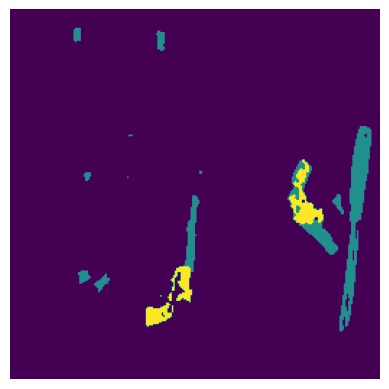

torch.Size([256, 256])

In [ ]:
plt.imshow(pred_seg)
plt.axis('off')
plt.show()
pred_seg.shape

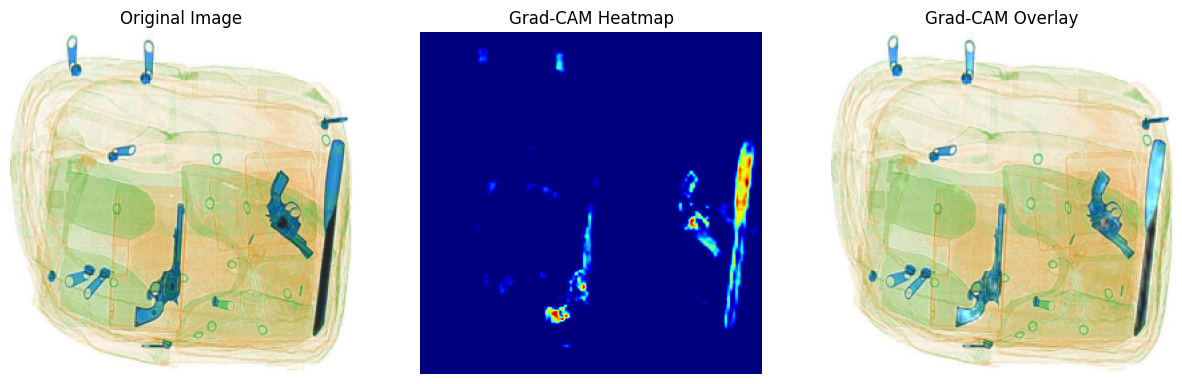

In [ ]:
import torch
from transformers import SegformerForSemanticSegmentation, SegformerFeatureExtractor
from PIL import Image
import numpy as np
from torchvision.transforms import functional as TF
import matplotlib.pyplot as plt

# Feature extractor setup
feature_extractor = SegformerFeatureExtractor()

# Define forward and backward hooks
activations = {}
gradients = {}

def forward_hook(module, input, output):
    if isinstance(output, tuple):
        activations['output'] = output[0]
    else:
        activations['output'] = output

def backward_hook(module, grad_input, grad_output):
    if isinstance(grad_output, tuple):
        gradients['output'] = grad_output[0]
    else:
        gradients['output'] = grad_output

# Register hooks on the target layer
def register_hooks(model, target_layer):
    for name, module in model.named_modules():
        if name == target_layer:
            module.register_forward_hook(forward_hook)
            module.register_backward_hook(backward_hook)
            break

target_layer = 'decode_head.classifier'
register_hooks(model, target_layer)

# Assuming you have access to the original image as a numpy array or image object in test_ds
original_image = test_ds[15]['pixel_values']  # Load the original image (unpreprocessed)

# Convert original image to numpy array if needed
if isinstance(original_image, Image.Image):
    original_image_np = np.array(original_image)
else:
    original_image_np = original_image  # Assuming it's already a numpy array

# Ensure the original image is in the shape (C, H, W)
if original_image_np.shape[0] == 1:  # Single channel image
    original_image_np = np.repeat(original_image_np, 3, axis=0)  # Convert to 3 channels
elif original_image_np.shape[0] == 3:  # RGB image
    pass
else:
    raise ValueError("Unexpected image shape. Expected (C, H, W) with C=1 or 3.")

# Preprocess the original image for the model
input_tensor = feature_extractor(images=original_image_np.transpose(1, 2, 0), return_tensors="pt")

# Move the input tensor to the same device as the model
input_tensor = input_tensor.to(model.device)  # Add this line

# Forward pass through the model
model.eval()  # Make sure the model is in evaluation mode
output = model(**input_tensor)
logits = output.logits

# Define target classes for Grad-CAM
target_classes = [1, 2]  # Adjust based on your needs

# Create Grad-CAM for each target class
grad_cams = []
for target_class in target_classes:
    if target_class >= logits.size(1):
        raise ValueError(f"Target class {target_class} is out of range for logits with size {logits.size(1)}")

    # Select logits for the target class and compute loss
    target_logits = logits[0, target_class]
    loss = target_logits.mean()  # Make sure it's a scalar

    # Backward pass for each class
    model.zero_grad()
    loss.backward(retain_graph=True)

    # Access the captured activations and gradients
    activation_maps = activations['output'].detach()
    gradient_maps = gradients['output'].detach()

    # Compute Grad-CAM for this target class
    weights = torch.mean(gradient_maps, dim=[0, 2, 3], keepdim=True)
    grad_cam = torch.sum(weights * activation_maps, dim=1, keepdim=True)
    grad_cam = torch.nn.functional.relu(grad_cam)

    # Resize Grad-CAM to the original image size
    grad_cam_resized = TF.resize(grad_cam, size=(original_image_np.shape[1], original_image_np.shape[2]))
    grad_cam_resized = grad_cam_resized - grad_cam_resized.min()
    grad_cam_resized = grad_cam_resized / grad_cam_resized.max()

    # Convert Grad-CAM to numpy array
    grad_cam_np = grad_cam_resized.squeeze().detach().cpu().numpy()
    grad_cams.append(grad_cam_np)

# Aggregate Grad-CAMs (e.g., average for two classes)
combined_grad_cam = np.mean(np.array(grad_cams), axis=0)

# Normalize original image for display purposes (if needed)
original_image_np_normalized = original_image_np / 255.0  # Normalize to [0, 1] range if not already normalized
original_image_np_normalized = np.transpose(original_image_np_normalized, (1, 2, 0))  # Shape should be (H, W, C)

# Ensure heatmap has the shape (H, W, C)
heatmap = np.stack([combined_grad_cam] * 3, axis=-1)  # Convert to (H, W, C)

# Overlay Grad-CAM on the original image
overlay_image = np.clip(original_image_np_normalized + heatmap, 0, 1)

# Plot original image, Grad-CAM, and the overlay
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(original_image_np_normalized)  # Use the untouched original image
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Grad-CAM Heatmap')
plt.imshow(combined_grad_cam, cmap='jet')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Grad-CAM Overlay')
plt.imshow(overlay_image)
plt.axis('off')

plt.show()


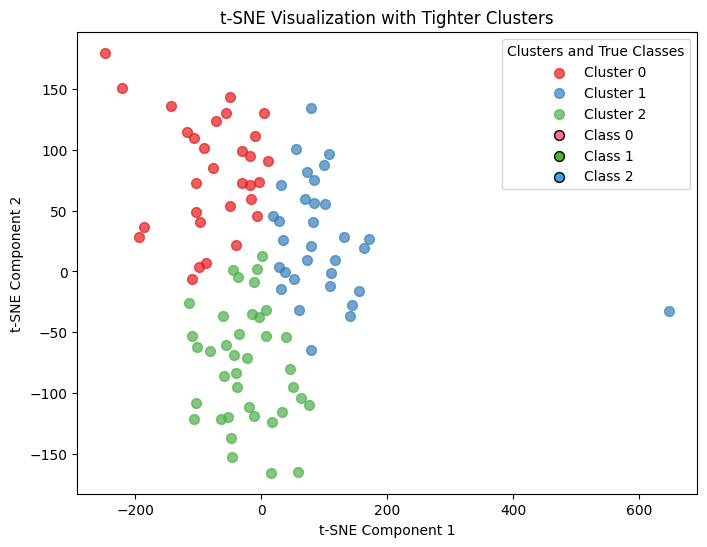

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import numpy as np

# Assuming 'features' is your model's output representations (N_samples, N_features)
# and 'labels' is the corresponding class labels (0: background, 1: knife, 2: gun)

# Example dummy data: replace this with actual model output and labels
features = np.random.rand(100, 512)  # Example features (100 samples, 512-dimensional features)
labels = np.random.randint(0, 3, size=(100,))  # Example labels (0: background, 1: knife, 2: gun)

# Perform t-SNE dimensionality reduction with lower perplexity and a custom learning rate
tsne = TSNE(n_components=2, random_state=42, perplexity=5, learning_rate=200)
features_tsne = tsne.fit_transform(features)

# Perform k-means clustering
n_clusters = 3

  # Define the number of clusters, adjust this if needed
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(features_tsne)

# Plot the t-SNE graph with clusters
plt.figure(figsize=(8, 6))

# Create color palettes for clusters and actual labels
palette_clusters = sns.color_palette("Set1", n_clusters)
palette_labels = sns.color_palette("husl", len(np.unique(labels)))

# Plot each cluster in a different color
for cluster in range(n_clusters):
    plt.scatter(features_tsne[clusters == cluster, 0], features_tsne[clusters == cluster, 1],
                label=f'Cluster {cluster}', color=palette_clusters[cluster], s=50, alpha=0.7)

# Optionally, plot the true labels for comparison (Class 0 and Class 1)
for i, label in enumerate(np.unique(labels)):
    plt.scatter([], [], label=f'Class {label}', color=palette_labels[i], s=50, edgecolor='k')

# Add a legend and title
plt.legend(title="Clusters and True Classes")
plt.title('t-SNE Visualization with Tighter Clusters')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

# Show the plot
plt.show()
